# TOP
LLM:
 - půjdu volit nebo ne - voted / not voted
 - podmíněne koho jsem volil
 - ve voting_results nesčítají řádky na 1 (nutno normalizovat a reportovat)

lidi:
 - jdu volit / nebo ne -- koho
 - nevím / nechci uvést -- drop
 - možnosti: nebyl jsem volit / nevím / nechci uvést / strana XY

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from utils.constants import (
    MODELS, PARTY_COLUMNS_2021, COUNTRY, VOTED, NOT_VOTED, PROMPT,
    GPT_41_NANO, GPT_41, GPT_4o_MINI, GPT_4o,
    ANO, SPOLU, PIRSTAN, SPD, PRISAHA, CSSD, KSCM, TSS, JINA_STRANA,
)
from utils.client import OpenAIClient
from utils.voting import VotingProbabilities, VotingPick
from utils.io_results import create_parameter_description

# MODELS = ["gpt_4_1", "gpt_4_1_nano", "gpt_4o", "gpt_4o_mini"]
MODELS = [GPT_41_NANO, GPT_41, GPT_4o_MINI, GPT_4o]
PARTIES = [PIRSTAN, SPOLU, ANO, SPD, PRISAHA, TSS, CSSD, KSCM, JINA_STRANA]

# Define the common path for CSV files
DATA_DIR = r"data"
RESULTS_DIR = r"results"
CSV_DIR = RESULTS_DIR  # legacy alias
IMG_DIR = r"img"

INCLUDE_NON_VOTERS = False


In [85]:
def drop_both(df: pd.DataFrame) -> pd.DataFrame:
    """
    Drop 'Voted' and 'Not Voted' columns
    """
    df2 = df.copy()
    to_drop = [c for c in [VOTED, NOT_VOTED] if c in df2.columns]
    if to_drop:
        df2 = df2.drop(columns=to_drop)
    # Renormalize remaining columns per row to sum to 1. Safe against divide-by-zero.
    # row_sums = df2.sum(axis=1)
    # df2 = df2.div(row_sums.replace(0, np.nan), axis=0).fillna(0.0)
    return df2

def drop_voted(df: pd.DataFrame) -> pd.DataFrame:
    """
    Multiply all party columns (all except 'Voted' and 'Not Voted') by the 'Voted' column row-wise,
    then drop 'Voted'. Keep 'Not Voted' unchanged.
    """
    df2 = df.copy()
    # party_cols = [c for c in df2.columns if c not in ['Voted', 'Not Voted']]
    party_cols = PARTIES
    if VOTED in df2.columns and party_cols:
        df2.loc[:, party_cols] = df2[party_cols].mul(df2[VOTED], axis=0)
        df2 = df2.drop(columns=[VOTED])
    elif VOTED in df2.columns:
        df2 = df2.drop(columns=[VOTED])
    return df2

def load_csv_files(csv_dir=None, models=None, drop_voted_flag=False, drop_both_flag=False, voting_class=VotingProbabilities):
    if csv_dir is None:
        csv_dir = RESULTS_DIR
    if models is None:
        models = MODELS

    panel_data = pd.read_csv(os.path.join(DATA_DIR, "clean_data.csv"), index_col=0)

    election_data = pd.read_csv(os.path.join(DATA_DIR, "election_data.csv")).set_index("region")
    if drop_both_flag:
        election_data = drop_both(election_data)
    elif drop_voted_flag:
        election_data = drop_voted(election_data)

    voting_results_dict = {}
    for model in models:
        fname = f"voting_results_{create_parameter_description(OpenAIClient, model, voting_class, 3880, 0.0)}.csv"
        voting_results = pd.read_csv(os.path.join(csv_dir, fname), index_col=0)
        voting_results = voting_results.loc[:, ~voting_results.columns.str.startswith("Unnamed")].drop(columns=[PROMPT], errors="ignore")
        if drop_both_flag:
            voting_results = drop_both(voting_results)
        elif drop_voted_flag:
            voting_results = drop_voted(voting_results)
        voting_results_dict[model] = voting_results

    return panel_data, election_data, voting_results_dict
# panel_data, election_data, voting_results_dict = load_csv_files(drop_voted_flag=True, drop_both_flag=True)
# panel_data, election_data, voting_results_dict = load_csv_files(drop_voted_flag=False, drop_both_flag=False)
panel_data, election_data, voting_results_dict = load_csv_files(drop_voted_flag=True, drop_both_flag=False)


In [86]:
def load_latent_prefs(csv_dir=None, models=None, drop_voted_flag=False, drop_both_flag=False):
    if csv_dir is None:
        csv_dir = RESULTS_DIR
    if models is None:
        models = MODELS

    res = dict()
    for model in models:
        latent_prefs = pd.read_csv(os.path.join(csv_dir, f"LatentPreferences_{model}_citizen_prompt.csv"), index_col=0)
        latent_prefs = latent_prefs.set_index('region')
        if drop_both_flag:
            latent_prefs = drop_both(latent_prefs)
        elif drop_voted_flag:
            latent_prefs = drop_voted(latent_prefs)
        res[model+"-citizen"] = latent_prefs

    for model in models:
        latent_prefs = pd.read_csv(os.path.join(csv_dir, f"LatentPreferences_{model}_direct_prompt.csv"), index_col=0)
        latent_prefs = latent_prefs.set_index('region')
        if drop_both_flag:
            latent_prefs = drop_both(latent_prefs)
        elif drop_voted_flag:
            latent_prefs = drop_voted(latent_prefs)
        res[model+"-direct"] = latent_prefs

    return res

def load_agentury(csv_dir=None, drop_voted_flag=False, drop_both_flag=False):
    if csv_dir is None:
        csv_dir = DATA_DIR

    agentury = pd.read_csv(os.path.join(csv_dir, "agentury.csv"), index_col=0, delimiter=';').dropna()
    if drop_both_flag:
        agentury = drop_both(agentury)
    elif drop_voted_flag:
        agentury = drop_voted(agentury)
    return agentury

latent_prefs = load_latent_prefs()
agentury = load_agentury()

# Statistical significance

## MANOVA

In [87]:
for iv in ['gender', "age", "education_level", "income_range", "interest_in_politics", "region","district", "town_size", "employment_status", "living_standard"]:
    print(panel_data[iv].value_counts())

gender
muž     1951
žena    1929
Name: count, dtype: int64
age
42    125
47    122
49    118
41    118
46    116
43    116
44    113
51    113
48    113
40    112
31    108
56    107
38    105
58    100
30     99
59     98
50     97
57     96
60     93
53     92
32     91
39     90
36     89
52     88
33     87
29     87
37     78
27     77
61     72
28     70
62     67
34     67
23     66
21     65
63     65
22     64
55     60
20     60
24     59
26     57
25     46
54     42
18     42
19     41
64     36
35     25
45     24
65      4
Name: count, dtype: int64
education_level
základní + středoškolské vzdělání bez maturity    1587
středoškolské vzdělání s maturitou                1392
vysokoškolské vzdělání                             901
Name: count, dtype: int64
income_range
30.001 - 40.000 Kč    763
25.001 - 30.000 Kč    647
20.001 - 25.000 Kč    583
Do 15.000 Kč          529
40.001 - 60.000 Kč    446
15.001 - 20.000 Kč    403
60.001 - 80.000 Kč     98
Vice než 80.000 Kč     64
Nam

In [88]:
import re
from statsmodels.multivariate.manova import MANOVA


def _helmert_submatrix(K: int) -> np.ndarray:
    """
    Orthonormal Helmert sub-matrix of shape (K, K-1).
    Columns form an orthonormal basis for the subspace orthogonal to 1_K.
    """
    if K < 2:
        raise ValueError("K must be >= 2 for an ILR transform.")
    H = np.zeros((K, K - 1), dtype=float)
    for j in range(1, K):  # j=1..K-1
        # First j entries: 1/sqrt(j*(j+1)), entry j+1: -j/sqrt(j*(j+1))
        denom = np.sqrt(j * (j + 1))
        H[:j, j - 1] = 1.0 / denom
        H[j,  j - 1] = -j / denom
    return H

def ilr_transform_df(
    df: pd.DataFrame,
    cols: list[str] = None,
    eps: float = 1e-12,
    renormalize: bool = True,
    prefix: str = "ilr_",
    return_basis: bool = False,
) -> pd.DataFrame | tuple[pd.DataFrame, np.ndarray]:
    """
    ILR transform for compositional data in `cols` (variables in columns).
    Each row is treated as one composition (e.g., probability distribution).

    Steps:
      1) Replace zeros / negatives via clipping to `eps`
      2) Optionally renormalize each row to sum to 1
      3) Compute ILR coordinates using an orthonormal Helmert basis

    Returns:
      - df_out with K-1 new columns (ILR coords)
      - optionally also returns the basis matrix (K x (K-1))
    """
    if eps <= 0:
        raise ValueError("eps must be > 0.")
    if cols is None:
        cols = df.columns
    if any(c not in df.columns for c in cols):
        missing = [c for c in cols if c not in df.columns]
        raise KeyError(f"Missing columns in df: {missing}")

    X = df[cols].to_numpy(dtype=float)

    # Clip to avoid log(0) and invalid values
    X = np.clip(X, eps, None)

    # Renormalize rows to sum to 1 (recommended for probabilities/compositions)
    if renormalize:
        row_sums = X.sum(axis=1, keepdims=True)
        # Avoid division by zero (shouldn't happen after clipping, but safe)
        row_sums = np.clip(row_sums, eps, None)
        X = X / row_sums

    K = X.shape[1]
    V = _helmert_submatrix(K)  # (K, K-1)

    # ILR = log(X) @ V
    Z = np.log(X) @ V  # (N, K-1)

    out = df.copy()
    ilr_cols = [f"{prefix}{i+1}" for i in range(K - 1)]
    out[ilr_cols] = Z
    return (out, V) if return_basis else out

def _sanitize_name(name: str) -> str:
    # Replace anything not alphanumeric or `_` with `_`
    return re.sub(r"\W+", "_", name.strip())

def run_panel_manova(panel_data: pd.DataFrame,
                     voting_results_dict: dict[str, pd.DataFrame],
                     independent_cols: list[str],
                     ilr_transform = False,
                     ) -> dict[str, dict]:
    reports: dict[str, dict] = {}

    for model, probs in voting_results_dict.items():
        merged = panel_data.join(probs, how="inner", rsuffix=f"_{model}").copy()
        dep_original = probs.columns.tolist()

        # Build a mapping original_name -> safe_name just for the formula
        dep_safe = {col: _sanitize_name(col) for col in dep_original}

        # Create formula\-safe aliases as views of the same data
        for orig, safe in dep_safe.items():
            merged[safe] = merged[orig]

        # Type handling
        for orig in dep_original:
            merged[orig] = pd.to_numeric(merged[orig], errors="coerce")
        for col in independent_cols:
            if merged[col].dtype == "object":
                merged[col] = merged[col].astype("category")

        merged = merged.dropna(subset=dep_original + independent_cols)

        if merged.empty:
            continue

        icols = dep_safe.values()
        if ilr_transform:
            merged = ilr_transform_df(merged, cols=icols)
            icols = [f"ilr_{i}" for i in range(1, len(icols))]

        # Use safe names on the LHS, original names on RHS
        lhs = " + ".join(icols)
        rhs = " + ".join(independent_cols)
        formula = f"{lhs} ~ {rhs}"
        reports[model] = MANOVA.from_formula(formula, data=merged).mv_test()

    return reports


panel_data, election_data, voting_results_dict = load_csv_files(drop_voted_flag=True, drop_both_flag=True) # we look at probability distributions on voters

# significant_tables = run_panel_manova(panel_data, voting_results_dict,
#                                       independent_cols=['gender', "age", "interest_in_politics", "living_standard"],
#                                       ilr_transform=True
#                                       )

# significant_tables = run_panel_manova(panel_data, voting_results_dict,
#                                       independent_cols=['gender', "age", "education_level", "income_range", "interest_in_politics", "region","district", "town_size", "employment_status", "living_standard"],
#                                       ilr_transform=True
#                                       )

significant_tables = run_panel_manova(panel_data, voting_results_dict,
                                      independent_cols=['gender', "age", "education_level", "income_range", "interest_in_politics", "region", "living_standard"],
                                      ilr_transform=True
                                      )

print(significant_tables["gpt-4o"])

                    Multivariate linear model
                                                                 
-----------------------------------------------------------------
          Intercept        Value  Num DF   Den DF  F Value Pr > F
-----------------------------------------------------------------
             Wilks' lambda 0.9590 8.0000 3492.0000 18.6781 0.0000
            Pillai's trace 0.0410 8.0000 3492.0000 18.6781 0.0000
    Hotelling-Lawley trace 0.0428 8.0000 3492.0000 18.6781 0.0000
       Roy's greatest root 0.0428 8.0000 3492.0000 18.6781 0.0000
-----------------------------------------------------------------
                                                                 
-----------------------------------------------------------------
            gender         Value  Num DF   Den DF  F Value Pr > F
-----------------------------------------------------------------
             Wilks' lambda 0.9163 8.0000 3492.0000 39.8680 0.0000
            Pillai's trace 0.0

In [89]:
def collect_manova_effects(reports: dict[str, object],
                           stats=("Wilks' lambda", "Pillai's trace")) -> pd.DataFrame:
    """
    Build a summary table of MANOVA effect sizes across models and predictors.

    Parameters
    ----------
    reports : dict
        {model_name: MultivariateTestResults} as returned by MANOVA.mv_test().
    stats : tuple[str]
        Which multivariate tests to extract ("Wilks' lambda", "Pillai's trace", ...).

    Returns
    -------
    pd.DataFrame
        Multi-index (model, predictor) with columns for chosen stats.
    """
    records: list[dict] = []

    for model, mv in reports.items():
        # mv is a MultivariateTestResults; its dict-like content is in mv.results
        for term, res in mv.results.items():
            if term == "Intercept":
                continue  # skip intercept

            stat_df = res["stat"]  # DataFrame with index of test names

            row = {"model": model, "predictor": term}
            for s in stats:
                if s in stat_df.index:
                    row[s] = stat_df.loc[s, "Value"]
            records.append(row)

    summary = pd.DataFrame.from_records(records)
    if summary.empty:
        return summary

    return summary.set_index(["model", "predictor"]).sort_index()
effects_summary = collect_manova_effects(significant_tables)
effects_summary

Wilks' lambda  Pillai's trace
model        predictor                                          
gpt-4.1      age                        0.831416        0.168584
             education_level            0.487536        0.518099
             gender                     0.878922        0.121078
             income_range               0.915070        0.087109
             interest_in_politics       0.963897        0.036500
             living_standard            0.758710        0.251946
             region                     0.759775        0.256909
gpt-4.1-nano age                        0.984719        0.015281
             education_level            0.960956        0.039250
             gender                     0.982149        0.017851
             income_range               0.948481        0.052311
             interest_in_politics       0.682894        0.341280
             living_standard            0.915283        0.086756
             region                     0.928976        0.073000
gpt-4o       age                        0.885679        0.114321
             education_level            0.798409        0.203608
             gender                     0.916308        0.083692
             income_range               0.966580        0.033783
             interest_in_politics       0.926822        0.074782
             living_standard            0.779991        0.227262
             region                     0.832160        0.174509
gpt-4o-mini  age                        0.960798        0.039202
             education_level            0.926061        0.075127
             gender                     0.930983        0.069017
             income_range               0.929918        0.071364
             interest_in_politics       0.813989        0.192798
             living_standard            0.771163        0.244164
             region                     0.948674        0.052355

Wilks' lambda = 0.1892 (low)
Pillai's trace = 0.9565 (close to 1)
=> Very strong multivariate association.

Wilks' lambda = 0.5575, Pillai's trace = 0.4936
=> Moderate/strong effect.

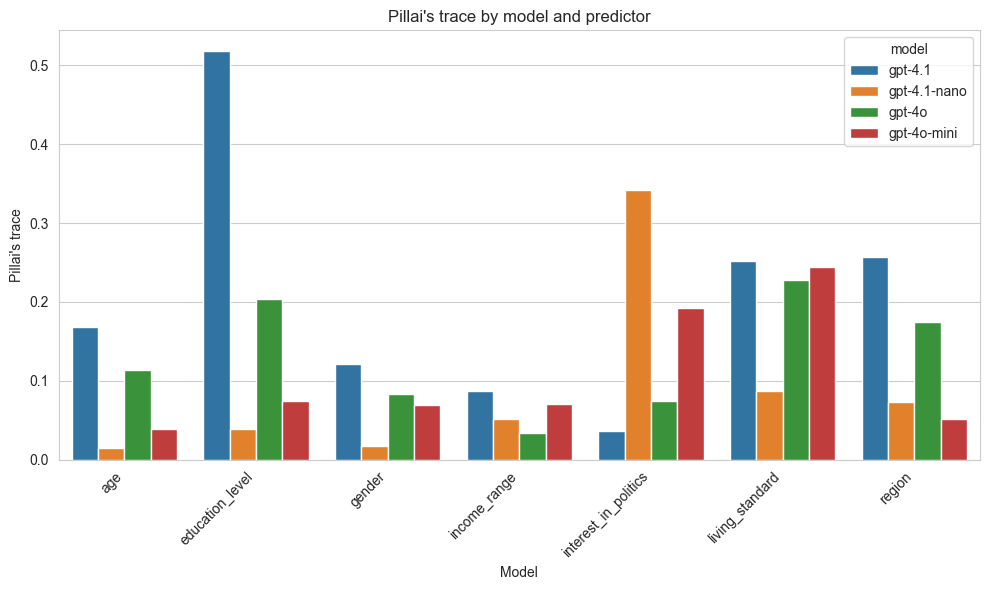

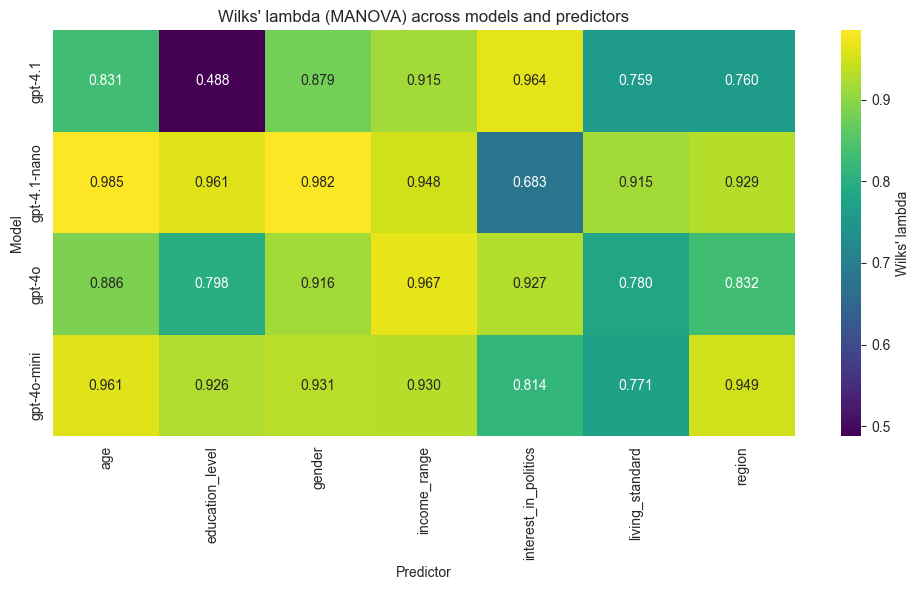

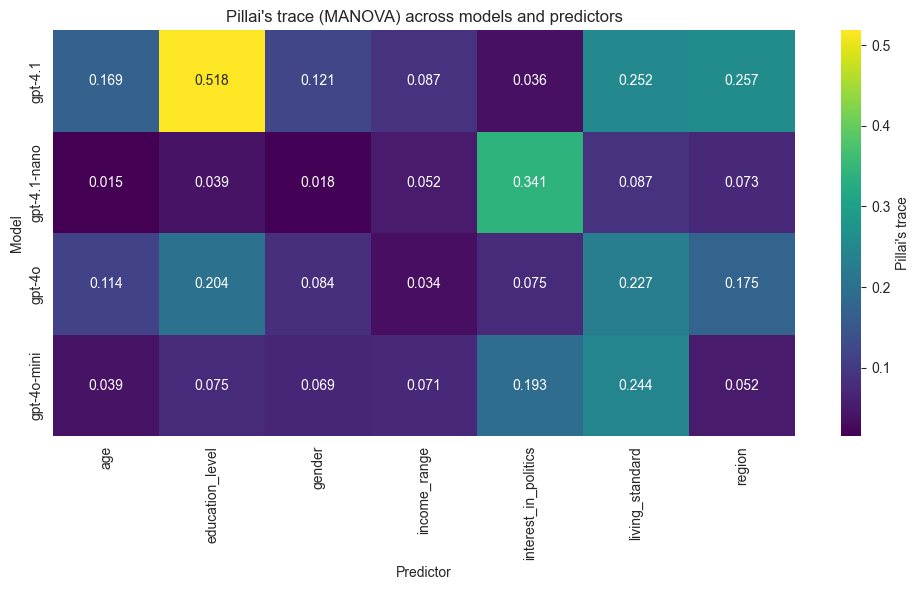

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_manova_effects(
    effects_df: pd.DataFrame,
    stat: str = "Pillai's trace",
    kind: str = "bar",  # "bar" or "heatmap"
    figsize: tuple[int, int] = (10, 6),
) -> None:
    """
    Visualize MANOVA effect statistics across models and predictors.

    Parameters
    ----------
    effects_df : pd.DataFrame
        Output of collect_manova_effects: index (model, predictor),
        columns include `stat` (e.g. "Pillai's trace", "Wilks' lambda").
    stat : str
        Which statistic column to visualize.
    kind : str
        "bar" for grouped barplot, "heatmap" for matrix view.
    figsize : tuple[int, int]
        Figure size in inches.
    """
    if effects_df.empty:
        print("No data to plot.")
        return

    if stat not in effects_df.columns:
        print(f"Statistic {stat!r} not found in effects_df.")
        return

    df = effects_df.reset_index()  # columns: model, predictor, stat, ...

    plt.figure(figsize=figsize)

    if kind == "bar":
        # grouped bar: x=model, hue=predictor, y=stat
        sns.barplot(
            data=df,
            x="predictor",
            y=stat,
            hue="model",
            dodge=True,
        )
        plt.xticks(rotation=45, ha="right")
        plt.ylabel(stat)
        plt.xlabel("Model")
        plt.title(f"{stat} by model and predictor")
        plt.tight_layout()
        plt.show()

    elif kind == "heatmap":
        # pivot to matrix: rows=models, cols=predictors
        pivot = df.pivot(index="model", columns="predictor", values=stat)
        sns.heatmap(
            pivot,
            annot=True,
            fmt=".3f",
            cmap="viridis",
            cbar_kws={"label": stat},
        )
        plt.ylabel("Model")
        plt.xlabel("Predictor")
        plt.title(f"{stat} (MANOVA) across models and predictors")
        plt.tight_layout()
        plt.show()
    else:
        print("kind must be 'bar' or 'heatmap'.")

# `effects` is the DataFrame returned by collect_manova_effects(...)
plot_manova_effects(effects_summary, stat="Pillai's trace", kind="bar")
plot_manova_effects(effects_summary, stat="Wilks' lambda", kind="heatmap")
plot_manova_effects(effects_summary, stat="Pillai's trace", kind="heatmap")

## PERMANOVA

In [91]:
import numpy as np
import pandas as pd
from typing import Dict, List, Literal
from dataclasses import dataclass
import logging

logger = logging.getLogger(__name__)


# --- distance utilities -----------------------------------------------------


def _pairwise_distances(X: np.ndarray, metric: str) -> np.ndarray:
    """
    Compute pairwise distances for multiple metrics.

    Supported metrics:
      - 'euclidean_ilr': ordinary Euclidean on X (assumed ILR coords)
      - 'hellinger': Hellinger distance for compositions in rows of X
      - 'l1': L1 distance (sum |x_i - y_i|)
      - 'mae': mean absolute error per row pair
      - 'correlation': sqrt(2 * (1 - r_ij)), where r_ij is Pearson correlation
      - 'js': Jensen–Shannon distance for probability vectors in X
    """
    metric = metric.lower()
    n = X.shape[0]

    if metric == "euclidean_ilr":
        # standard Euclidean distances
        diff = X[:, None, :] - X[None, :, :]
        D = np.sqrt(np.sum(diff ** 2, axis=-1))
        return D

    if metric in ("hellinger", "js"):
        # require nonnegative, rows summing to 1 (probabilities)
        X = np.clip(X, 1e-12, None)
        row_sums = X.sum(axis=1, keepdims=True)
        X = X / row_sums

    if metric == "hellinger":
        # H(p,q) = 1/sqrt(2) * ||sqrt(p) - sqrt(q)||_2
        sqrtX = np.sqrt(X)
        diff = sqrtX[:, None, :] - sqrtX[None, :, :]
        D = np.sqrt(np.sum(diff ** 2, axis=-1)) / np.sqrt(2.0)
        return D

    if metric in ("l1", "mae"):
        diff = np.abs(X[:, None, :] - X[None, :, :])
        if metric == "l1":
            D = np.sum(diff, axis=-1)
        else:  # mae
            D = np.mean(diff, axis=-1)
        return D

    if metric == "correlation":
        # 1 - corr(i,j), then transform to a metric: sqrt(2*(1-r))
        Xc = X - X.mean(axis=0, keepdims=True)
        # covariance matrix of rows
        G = Xc @ Xc.T
        diag = np.sqrt(np.diag(G))
        denom = np.outer(diag, diag)
        with np.errstate(divide="ignore", invalid="ignore"):
            R = np.where(denom > 0, G / denom, 0.0)
        R = np.clip(R, -1.0, 1.0)
        D = np.sqrt(2.0 * (1.0 - R))
        return D

    if metric == "js":
        # Jensen–Shannon distance
        # JS(p,q) = sqrt( 0.5*KL(p||m) + 0.5*KL(q||m) ), m=(p+q)/2
        X = np.clip(X, 1e-12, None)
        D = np.zeros((n, n), dtype=float)
        for i in range(n):
            p = X[i]
            for j in range(i + 1, n):
                q = X[j]
                m = 0.5 * (p + q)
                kl_pm = np.sum(p * (np.log(p) - np.log(m)))
                kl_qm = np.sum(q * (np.log(q) - np.log(m)))
                js = 0.5 * kl_pm + 0.5 * kl_qm
                d = float(np.sqrt(js))
                D[i, j] = D[j, i] = d
        return D

    raise ValueError(f"Unsupported distance metric: {metric}")


# --- simple PERMANOVA implementation ----------------------------------------


@dataclass
class PermanovaResult:
    df: int
    ss: float
    ms: float
    f_value: float
    p_value: float
    n_perm: int



def _permanova_one_factor(
    D: np.ndarray,
    X: np.ndarray,
    n_perm: int = 999,
    seed: int | None = None,
) -> PermanovaResult:
    """
    Distance-based PERMANOVA for predictors X (n x p) on distance matrix D (n x n).
    Implements Anderson (2001) style sums of squares; guards against negative SS
    from numerical noise.
    """
    rng = np.random.default_rng(seed)
    n = D.shape[0]

    # Gower-centred matrix G from squared distances
    D2 = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    G = -0.5 * J @ D2 @ J

    # Design with intercept
    X_design = np.column_stack([np.ones(n), X])
    XtX_inv = np.linalg.pinv(X_design.T @ X_design)
    H = X_design @ XtX_inv @ X_design.T
    I = np.eye(n)

    # Sums of squares
    SS_total = float(np.trace(G))
    SS_effect = float(np.trace(H @ G))
    SS_resid = float(np.trace((I - H) @ G))

    # Guard against tiny negatives from numerical noise
    SS_total = max(SS_total, 0.0)
    SS_effect = max(SS_effect, 0.0)
    SS_resid = max(SS_resid, 0.0)

    df_effect = X.shape[1]              # p predictors (excluding intercept)
    df_resid = max(n - 1 - df_effect, 1)

    MS_effect = SS_effect / df_effect if df_effect > 0 else np.nan
    MS_resid = SS_resid / df_resid if df_resid > 0 else np.nan
    F_obs = MS_effect / MS_resid if MS_resid > 0 else np.nan

    # Permutation test
    n_ge = 0
    for _ in range(n_perm):
        perm_idx = rng.permutation(n)
        Xp = X[perm_idx, :]
        Xp_design = np.column_stack([np.ones(n), Xp])
        XtX_inv_p = np.linalg.pinv(Xp_design.T @ Xp_design)
        Hp = Xp_design @ XtX_inv_p @ Xp_design.T

        SS_effect_p = float(np.trace(Hp @ G))
        SS_resid_p = float(np.trace((I - Hp) @ G))

        SS_effect_p = max(SS_effect_p, 0.0)
        SS_resid_p = max(SS_resid_p, 0.0)

        MS_e_p = SS_effect_p / df_effect if df_effect > 0 else np.nan
        MS_r_p = SS_resid_p / df_resid if df_resid > 0 else np.nan
        F_p = MS_e_p / MS_r_p if MS_r_p > 0 else np.nan

        if not np.isnan(F_p) and F_p >= F_obs:
            n_ge += 1

    p_val = (n_ge + 1) / (n_perm + 1)

    return PermanovaResult(
        df=df_effect,
        ss=SS_effect,
        ms=MS_effect,
        f_value=F_obs,
        p_value=p_val,
        n_perm=n_perm,
    )


# --- ILR transform (reusing your existing one) ------------------------------


def _helmert_submatrix(K: int) -> np.ndarray:
    if K < 2:
        raise ValueError("K must be >= 2 for an ILR transform.")
    H = np.zeros((K, K - 1), dtype=float)
    for j in range(1, K):
        denom = np.sqrt(j * (j + 1))
        H[:j, j - 1] = 1.0 / denom
        H[j, j - 1] = -j / denom
    return H


def ilr_transform_array(
    X: np.ndarray,
    eps: float = 1e-12,
    renormalize: bool = True,
) -> np.ndarray:
    X = np.asarray(X, dtype=float)
    X = np.clip(X, eps, None)
    if renormalize:
        row_sums = X.sum(axis=1, keepdims=True)
        row_sums = np.clip(row_sums, eps, None)
        X = X / row_sums
    K = X.shape[1]
    V = _helmert_submatrix(K)
    Z = np.log(X) @ V
    return Z


# --- main interface: run_panel_permanova ------------------------------------


DistanceName = Literal[
    "euclidean_ilr",
    "hellinger",
    "l1",
    "mae",
    "correlation",
    "js",
]


def run_panel_permanova(
    panel_data: pd.DataFrame,
    voting_results_dict: Dict[str, pd.DataFrame],
    independent_cols: List[str],
    distance: DistanceName = "euclidean_ilr",
    ilr_for_euclidean: bool = True,
    n_perm: int = 999,
    seed: int | None = None,
) -> Dict[str, Dict]:
    """
    PERMANOVA for each model in `voting_results_dict` with the same interface
    style as run_panel_manova.

    Parameters
    ----------
    panel_data : pd.DataFrame
        Independent variables (categorical, numeric).
    voting_results_dict : dict[str, pd.DataFrame]
        Dependent compositional data (e.g. vote probabilities) per model.
    independent_cols : list[str]
        Column names in panel_data to use as predictors.
    distance : DistanceName
        Distance metric for PERMANOVA:
          - 'euclidean_ilr' (default): Euclidean in ILR space
          - 'hellinger', 'l1', 'mae', 'correlation', 'js'
    ilr_for_euclidean : bool
        If True and distance == 'euclidean_ilr', apply ILR to compositions first.
    n_perm : int
        Number of permutations for p-value.
    seed : int | None
        RNG seed for reproducibility.

    Returns
    -------
    dict[str, dict]
        For each model key: dict with status, result, report.
    """
    if not isinstance(panel_data, pd.DataFrame):
        raise ValueError("`panel_data` must be a pandas DataFrame.")
    missing_cols = [c for c in independent_cols if c not in panel_data.columns]
    if missing_cols:
        raise ValueError(f"Independent columns missing from panel data: {missing_cols}")

    results: Dict[str, Dict] = {}

    for model, probs in voting_results_dict.items():
        entry_report: Dict[str, object] = {
            "model": model,
            "independent_cols": list(independent_cols),
            "distance": distance,
        }

        try:
            merged = panel_data.join(probs, how="inner", rsuffix=f"_{model}").copy()
            dep_cols = probs.columns.tolist()

            # ensure numeric dependent data
            for c in dep_cols:
                merged[c] = pd.to_numeric(merged[c], errors="coerce")

            # ensure independent variables exist and drop NaNs
            merged = merged.dropna(subset=dep_cols + independent_cols)
            if merged.empty:
                raise ValueError("No data left after dropna for model " + model)

            Y = merged[dep_cols].to_numpy(dtype=float)

            # distance space
            if distance == "euclidean_ilr":
                if ilr_for_euclidean:
                    Y_space = ilr_transform_array(Y, eps=1e-12, renormalize=True)
                else:
                    Y_space = Y
            else:
                # other distances operate in probability space
                Y_space = Y

            D = _pairwise_distances(Y_space, metric=distance)

            # dummy-encode predictors with meaningful names
            X_frames = []
            for col in independent_cols:
                s = merged[col]
                if s.dtype == "object":
                    s = s.astype("category")
                dummies = pd.get_dummies(
                    s,
                    prefix=col,
                    drop_first=True,
                    dtype=float,
                )
                X_frames.append(dummies)
            if not X_frames:
                raise ValueError("No independent variables provided.")
            X = pd.concat(X_frames, axis=1).to_numpy(dtype=float)

            # run PERMANOVA
            perm_res = _permanova_one_factor(D, X, n_perm=n_perm, seed=seed)

            results[model] = {
                "status": "ok",
                "result": perm_res,
                "report": {
                    **entry_report,
                    "n_obs": int(D.shape[0]),
                    "n_predictors": int(X.shape[1]),
                },
            }

        except Exception as exc:
            logger.exception("PERMANOVA failed for model %s: %s", model, exc)
            results[model] = {
                "status": "error",
                "result": None,
                "report": entry_report,
                "error": f"{type(exc).__name__}: {exc}",
            }

    return results

panel_data, election_data, voting_results_dict = load_csv_files(
    drop_voted_flag=True,
    drop_both_flag=False,
)

# perma_results = run_panel_permanova(
#     panel_data,
#     voting_results_dict,
#     independent_cols=[
#         "gender",
#         "age",
#         "education_level",
#         "income_range",
#         "interest_in_politics",
#         "region",
#         "living_standard",
#     ],
#     distance="hellinger",  # or 'euclidean_ilr', 'l1', 'mae', 'correlation', 'js'
#     n_perm=100,
#     seed=42,
# )
#
# print(perma_results["gpt-4o"]["result"])


a# Distances

In [92]:
import numpy as np
import pandas as pd
from scipy.stats import entropy, wasserstein_distance
from scipy.spatial.distance import jensenshannon


def _sanitize_weights(w, tol=1e-12):
    w = np.asarray(w, dtype=float)
    # replace NaN/inf with 0
    w = np.where(np.isfinite(w), w, 0.0)
    # clip tiny negatives due to numerical noise
    w = np.where(w < 0, 0.0, w)
    s = w.sum()
    if not np.isfinite(s) or s <= tol:
        return None  # invalid weights
    # normalize to sum 1 (optional but typical for probabilities)
    return w / s

def safe_wasserstein_from_probs(p, q, tol=1e-12):
    p_safe = _sanitize_weights(p, tol)
    q_safe = _sanitize_weights(q, tol)
    if p_safe is None or q_safe is None:
        return np.nan  # or 0.0, depending on your needs
    positions = np.arange(len(p_safe))
    return float(wasserstein_distance(positions, positions, p_safe, q_safe))


def calculate_distances(df1: pd.DataFrame, df2: pd.DataFrame, tol: float = 1e-8) -> pd.DataFrame:
    """
    For each row in df1 calculate distances between corresponding rows in df2.
    Report if any row does not form a probability distribution.
    Returns dataframe with same rows as df1 and with distances in columns.
    For KL divergence: df1 is the ground truth (P) and df2 is the approximation (Q)
    """
    if not df1.index.equals(df2.index):
        raise ValueError("df1 and df2 must have the same index (rows).")
    if not df1.columns.equals(df2.columns):
        raise ValueError("df1 and df2 must have the same columns.")

    rows = df1.index
    metrics = {
        "MAE": [],
        "RMSE": [],
        "Correlation": [],
        "KL Divergence": [],
        "Jensen-Shannon Divergence": [],
        "Wasserstein Distance": []
    }

    invalid_rows = []      # rows with negatives or zero sums (cannot normalize)
    nonprob_rows = []      # rows that do not sum to 1 (will be normalized)

    for r in rows:
        p = df1.loc[r].astype(float).to_numpy(copy=True)
        q = df2.loc[r].astype(float).to_numpy(copy=True)

        sum_p, sum_q = p.sum(), q.sum()
        neg_p, neg_q = (p < 0).any(), (q < 0).any()

        if neg_p or neg_q or sum_p <= 0 or sum_q <= 0:
            invalid_rows.append(r)
            for k in metrics:
                metrics[k].append(np.nan)
            continue

        if not np.isclose(sum_p, 1.0, atol=tol, rtol=0) or not np.isclose(sum_q, 1.0, atol=tol, rtol=0):
            nonprob_rows.append(r)

        # Normalize to probability distributions
        p = p / sum_p
        q = q / sum_q

        # Smoothing for divergences
        eps = 1e-12
        p_safe = np.clip(p, eps, 1.0)
        q_safe = np.clip(q, eps, 1.0)
        p_safe /= p_safe.sum()
        q_safe /= q_safe.sum()

        mae = float(np.mean(np.abs(p - q)))
        rmse = float(np.sqrt(np.mean((p - q) ** 2)))

        if np.std(p) == 0 or np.std(q) == 0:
            corr = np.nan
        else:
            corr = float(np.corrcoef(p, q)[0, 1])

        kl_div = float(entropy(p_safe, q_safe))
        js_div = float(jensenshannon(p_safe, q_safe) ** 2)

        positions = np.arange(len(p))
        # w_dist = float(wasserstein_distance(positions, positions, p, q))
        w_dist = 1
        # w_dist = float(safe_wasserstein_from_probs(positions, positions, p, q))


        metrics["MAE"].append(mae)
        metrics["RMSE"].append(rmse)
        metrics["Correlation"].append(corr)
        metrics["KL Divergence"].append(kl_div)
        metrics["Jensen-Shannon Divergence"].append(js_div)
        metrics["Wasserstein Distance"].append(w_dist)

    if invalid_rows:
        print(f"{len(invalid_rows)} row(s) contain negative values or zero sum and were skipped: {list(invalid_rows)}")
    if nonprob_rows:
        print(f"{len(nonprob_rows)} row(s) did not sum to 1 and were normalized: {list(nonprob_rows)}")

    return pd.DataFrame(metrics, index=rows)

# Hardcoded population by volební kraj (approx., as of 2023-01-01; source: cs.wikipedia.org) WRONG NUMBERS BUT RANKING CORRECT
VOLEBNI_KRAJE_POPULATION = {
    "Hlavní město Praha": 1_389_000,
    "Středočeský kraj": 1_404_000,
    "Jihočeský kraj": 648_000,
    "Plzeňský kraj": 593_000,
    "Karlovarský kraj": 281_000,
    "Ústecký kraj": 822_000,
    "Liberecký kraj": 446_000,
    "Královéhradecký kraj": 551_000,
    "Pardubický kraj": 524_000,
    "Kraj Vysočina": 512_000,
    "Jihomoravský kraj": 1_195_000,
    "Olomoucký kraj": 632_000,
    "Zlínský kraj": 579_000,
    "Moravskoslezský kraj": 1_188_000,
}

def get_volebni_kraje_population_series() -> pd.Series:
    """
    Return hardcoded population as a pandas Series (index = region name).
    """
    s = pd.Series(VOLEBNI_KRAJE_POPULATION, dtype="int64")
    s.index.name = "region"
    s.name = "population"
    return s

def sort_df_by_volebni_kraje_population(df: pd.DataFrame,
                                        region_first: str = "Česko",
                                        ascending: bool = False) -> tuple[pd.DataFrame, list]:
    """
    Sort rows of `df` by hardcoded population. Keeps `region_first` first if present.
    Returns: (sorted_df, order_list)
    """
    pop = get_volebni_kraje_population_series()
    base_order = pop.sort_values(ascending=ascending).index.tolist()

    if region_first in df.index:
        base_order = [region_first] + [r for r in base_order if r != region_first]

    # Append any rows that are not in the population list (stable)
    tail = [r for r in df.index if r not in base_order]
    order = base_order + tail

    if df.index.is_unique:
        return df.reindex(order), order
    # Stable position mapping for duplicate indices
    pos = pd.Series(range(len(order)), index=pd.Index(order, dtype=object))
    rank = pd.Index(df.index).map(pos).fillna(len(order)).to_numpy()
    return df.iloc[rank.argsort(kind="mergesort")], order

# Example:
df1 = drop_both(election_data).sort_index()

model = MODELS[0]
df2 = panel_data.join(voting_results_dict[model]).groupby('region')[PARTIES].mean()

# Compute mean across columns (numeric only) and make it a one-row DataFrame
mean_df = voting_results_dict[model][PARTIES].mean().to_frame().T
mean_df['region'] = "Česko"
mean_df.set_index('region', inplace=True)
df2 = pd.concat([df2, mean_df]).sort_index().reindex(columns=df1.columns, index=df1.index)

metrics_df = calculate_distances(df1, df2)
pop_series = get_volebni_kraje_population_series()
metrics_df_sorted, order = sort_df_by_volebni_kraje_population(metrics_df, region_first="Česko", ascending=False)
metrics_df_sorted

15 row(s) did not sum to 1 and were normalized: ['Hlavní město Praha', 'Jihomoravský kraj', 'Jihočeský kraj', 'Karlovarský kraj', 'Kraj Vysočina', 'Královéhradecký kraj', 'Liberecký kraj', 'Moravskoslezský kraj', 'Olomoucký kraj', 'Pardubický kraj', 'Plzeňský kraj', 'Středočeský kraj', 'Zlínský kraj', 'Ústecký kraj', 'Česko']


,MAE,RMSE,Correlation,KL Divergence,Jensen-Shannon Divergence,Wasserstein Distance
region,,,,,,
Česko,0.027885,0.037840,0.925521,0.054933,0.013922,1
Středočeský kraj,0.034217,0.039862,0.925888,0.065742,0.016946,1
Hlavní město Praha,0.046329,0.059574,0.915406,0.119818,0.031674,1
Jihomoravský kraj,0.028956,0.034888,0.938765,0.060283,0.015133,1
Moravskoslezský kraj,0.040775,0.060552,0.779469,0.095451,0.022903,1
Ústecký kraj,0.047644,0.069171,0.741406,0.124123,0.030447,1
Jihočeský kraj,0.028257,0.037930,0.928864,0.047925,0.011861,1
Olomoucký kraj,0.030849,0.045188,0.874605,0.063105,0.015493,1
Plzeňský kraj,0.029258,0.042881,0.898649,0.060023,0.014819,1


## Final - prob dist guess

In [93]:
from copy import copy
from typing import Dict, List, Optional, Sequence, Tuple
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from math import ceil

# Assumes these exist in your project:
# - PARTIES: List[str]
# - drop_both(election_data) -> pd.DataFrame
# - calculate_distances(df1, df2) -> pd.DataFrame
# - sort_df_by_volebni_kraje_population(df, region_first, ascending) -> Tuple[pd.DataFrame, List]

def clean_voted_party_and_report(
    df: pd.DataFrame,
    voted_col: str = "voted_party",
    drop_value: str = "Nechci uvést",
    rename_from: str = "Nebyl/a jsem volit",
    rename_to: str = "Not Voted",
) -> Tuple[pd.DataFrame, Dict[str, int]]:
    """Drop rows with `drop_value` and rename `rename_from` -> `rename_to`. Print counts."""
    if voted_col not in df.columns:
        raise ValueError(f"Missing column: {voted_col}")

    df = df.copy()

    # 1) Drop "Nechci uvést"
    mask_drop = (df[voted_col] == drop_value) | (df[voted_col] == 'Nevím')
    dropped_count = int(mask_drop.sum())
    df = df.loc[~mask_drop]

    # 2) Rename "Nebyl/a jsem volit" -> "Not voted"
    mask_rename = df[voted_col] == rename_from
    renamed_count = int(mask_rename.sum())
    if renamed_count:
        df.loc[mask_rename, voted_col] = rename_to

    # 3) Report numbers of changes performed
    print(f"Dropped rows where {voted_col} == '{drop_value}': {dropped_count}")
    print(f"Renamed '{rename_from}' -> '{rename_to}': {renamed_count}")

    return df, {"dropped": dropped_count, "renamed": renamed_count}

def add_parties_one_hot(
    df: pd.DataFrame,
    parties: List[str],
    voted_col: str = "voted_party",
) -> pd.DataFrame:
    """Create one-hot party columns from `voted_col` with 0/1 per row for provided `parties`."""
    if voted_col not in df.columns:
        raise ValueError(f"Missing column: {voted_col}")
    df = df.copy()
    for p in parties:
        df[p] = (df[voted_col] == p).astype(int)
    return df

# def build_claimed_df2(
#     panel_data: pd.DataFrame,
#     df1: pd.DataFrame,
#     parties: List[str],
#     region_col: str = "region",
#     voted_col: str = "voted_party",
#     region_first: str = "Česko",
#     print_result: bool = True,
# ) -> pd.DataFrame:
#     """
#     Build df2 for 'claimed' from panel_data by:
#       - cleaning voted_party,
#       - one-hot encoding into `parties` columns,
#       - printing the resulting dataframe,
#       - grouping by region and taking mean,
#       - appending national mean 'Česko',
#       - aligning to df1 rows/columns.
#     """
#     if panel_data is None or panel_data.empty:
#         raise ValueError("panel_data is empty.")
#     if region_col not in panel_data.columns:
#         raise ValueError(f"Missing column: {region_col}")
#
#     # Steps 1,2,3
#     cleaned, _stats = clean_voted_party_and_report(panel_data, voted_col=voted_col)
#
#     # Step 4: one-hot over requested parties
#     claimed_ohe = add_parties_one_hot(cleaned, parties=parties, voted_col=voted_col)
#
#     # Step 6: print resulting dataframe
#     if print_result:
#         cols_to_print = [region_col, voted_col] + list(parties)
#         cols_to_print = [c for c in cols_to_print if c in claimed_ohe.columns]
#         print("Resulting 'claimed' DataFrame (after one-hot):")
#         print(claimed_ohe[cols_to_print])
#
#     # Step 7: aggregate by region and take the mean
#     df2_region = claimed_ohe.groupby(region_col)[parties].mean()
#
#     # Add national mean row 'Česko'
#     mean_df = claimed_ohe[parties].mean().to_frame().T
#     mean_df[region_col] = region_first
#     mean_df.set_index(region_col, inplace=True)
#
#     df2 = (
#         pd.concat([df2_region, mean_df])
#         .sort_index()
#         .reindex(columns=df1.columns, index=df1.index)
#     )
#     return df2


def _renorm_with_smoothing(df: pd.DataFrame, eps: float = 1e-6) -> pd.DataFrame:
    # Add small epsilon to avoid zeros, renormalize each row to sum to 1
    probs = df.fillna(0.0).astype(float)
    probs = probs + eps
    row_sums = probs.sum(axis=1)
    probs = probs.div(row_sums, axis=0).fillna(0.0)
    return probs

def build_claimed_df2(
    panel_data: pd.DataFrame,
    df1: pd.DataFrame,
    parties: List[str],
    agg_col: str = "region",
    voted_col: str = "voted_party",
    region_first: str = "Česko",
    print_result: bool = True,
    print_group_sizes: bool = True,
    voters_only: bool = True,      # <- exclude "Not voted" for apples-to-apples with election results
    smooth_eps: float = 1e-6,      # <- Laplace smoothing to stabilize KL
) -> pd.DataFrame:
    if not voters_only and NOT_VOTED not in parties:
        parties = copy(parties)
        parties += [NOT_VOTED]
    if agg_col not in panel_data.columns:
        raise ValueError(f"Missing aggregation column: {agg_col}")

    cleaned, _ = clean_voted_party_and_report(panel_data, voted_col=voted_col)
    if voters_only:
        # print("A"*20)
        # print(len(cleaned))
        cleaned = cleaned.loc[cleaned[voted_col] != "Not Voted"]
        # print("B"*20)
        # print(len(cleaned))

    claimed_ohe = add_parties_one_hot(cleaned, parties=parties, voted_col=voted_col)

    if print_result:
        cols_to_print = [c for c in [agg_col, voted_col, *parties] if c in claimed_ohe.columns]
        print("Resulting 'claimed' DataFrame (after one-hot, voters_only="
              f"{voters_only}):")
        print(claimed_ohe[cols_to_print].head(20))

    if print_group_sizes:
        sizes = claimed_ohe.groupby(agg_col).size().sort_values(ascending=False)
        print("Claimed group sizes by", agg_col)
        print(sizes)

    # Aggregate by agg_col and take means
    df2_group = claimed_ohe.groupby(agg_col)[parties].mean()

    # Add total mean row (e.g., 'Česko')
    mean_df = claimed_ohe[parties].mean().to_frame().T
    mean_df[agg_col] = region_first
    mean_df.set_index(agg_col, inplace=True)

    df2 = (
        pd.concat([df2_group, mean_df])
        .sort_index()
        .reindex(columns=df1.columns, index=df1.index)
    )

    # Critical: smooth and renormalize rows so KL is stable
    df2 = _renorm_with_smoothing(df2, eps=smooth_eps)
    return df2

def _model_colors(models: List[str]) -> Dict[str, str]:
    palette = [
        "#4C72B0", "#55A868", "#C44E52", "#8172B2",
        "#CCB974", "#64B5CD", "#8C8C8C", "#937860",
    ]
    return {m: palette[i % len(palette)] for i, m in enumerate(models)}

def make_distance_figure(
    model_to_metrics: Dict[str, pd.DataFrame],
    region_order: List,
    metrics: List[str],
    region_first: str = "Česko",
    ncols: int = 2,
    height_per_row: int = 350,
    template: str = "plotly_white",
    figure_width: Optional[int] = None,
    col_width: int = 520,
) -> go.Figure:
    n = len(metrics)
    ncols = max(1, int(ncols))
    nrows = ceil(n / ncols)

    fig = make_subplots(
        rows=nrows,
        cols=ncols,
        subplot_titles=[str(m) for m in metrics],
        horizontal_spacing=0.08,
        vertical_spacing=0.12,
    )

    models = list(model_to_metrics.keys())
    colors = _model_colors(models)
    cat_labels = [str(lbl) for lbl in region_order]
    cz_label = next((lbl for lbl in region_order if str(lbl) == region_first), None)
    baseline_model = models[0]

    for i, metric in enumerate(metrics):
        r = i // ncols + 1
        c = i % ncols + 1

        for model in models:
            s = model_to_metrics[model][metric].replace([float("inf"), float("-inf")], pd.NA)
            fig.add_trace(
                go.Scatter(
                    x=cat_labels,
                    y=s.values,
                    mode="lines+markers",
                    name=model,
                    line=dict(width=2, color=colors[model]),
                    hovertemplate=(
                        "Region=%{x}<br>"
                        + f"{metric}: " + "%{y:.6g}<br>"
                        + f"Model={model}<extra></extra>"
                    ),
                    legendgroup=model,
                    showlegend=(i == 0),
                ),
                row=r, col=c,
            )

        if cz_label is not None:
            cz_val = model_to_metrics[baseline_model].loc[cz_label, metric]
            if pd.notna(cz_val):
                fig.add_hline(
                    y=float(cz_val),
                    line_dash="dash",
                    line_color="#C44E52",
                    line_width=1.5,
                    row=r, col=c,
                )

        fig.update_xaxes(
            categoryorder="array",
            categoryarray=cat_labels,
            tickangle=45,
            row=r, col=c,
        )
        fig.update_yaxes(title_text="Distance", row=r, col=c)

    total_cells = nrows * ncols
    for j in range(n, total_cells):
        r = j // ncols + 1
        c = j % ncols + 1
        fig.update_xaxes(visible=False, row=r, col=c)
        fig.update_yaxes(visible=False, row=r, col=c)

    width = figure_width if figure_width is not None else max(800, ncols * col_width)
    fig.update_layout(
        height=max(350, nrows * height_per_row),
        width=width,
        title_text="Distance per metric by region (all models + claimed)",
        showlegend=True,
        hovermode="x unified",
        template=template,
        legend_title_text="Model",
        margin=dict(l=60, r=20, t=60, b=60),
    )
    return fig

def plot_distance_lines_from_voting_results(
    election_data: pd.DataFrame,
    panel_data: pd.DataFrame,
    voting_results_dict: Dict[str, pd.DataFrame],
    latent_prefs_dict: Dict[str, pd.DataFrame] = None,
    models: Optional[List[str]] = None,
    parties: Optional[List[str]] = None,
    region_first: str = "Česko",
    ncols: int = 2,
    height_per_row: int = 350,
    template: str = "plotly_white",
    ascending_population: bool = False,
    figure_width: Optional[int] = None,
    col_width: int = 520,
    distances: Optional[Sequence[str]] = None,
    include_claimed: bool = True,  # <- add claimed distances
) -> go.Figure:
    if parties is None:
        if "PARTIES" not in globals():
            raise ValueError("PARTIES must be provided or defined globally.")
        if INCLUDE_NON_VOTERS:
            parties = copy(PARTIES) + [NOT_VOTED]
        else:
            parties = copy(PARTIES)

    # df1 = drop_both(election_data).sort_index()
    df1 = drop_voted(election_data).sort_index()

    # Determine which models to include
    models = list(voting_results_dict.keys()) if not models else models

    model_to_metrics: Dict[str, pd.DataFrame] = {}
    region_order: Optional[List] = None
    metrics_names: Optional[List[str]] = None

    # Add model-based metrics
    for model in models:
        if model not in voting_results_dict:
            continue

        vr = voting_results_dict[model]
        df2_region = panel_data.join(vr).groupby("region")[parties].mean()

        mean_df = vr[parties].mean().to_frame().T
        mean_df["region"] = region_first
        mean_df.set_index("region", inplace=True)

        df2 = (
            pd.concat([df2_region, mean_df])
            .sort_index()
            .reindex(columns=df1.columns, index=df1.index)
        )

        metrics_df = calculate_distances(df1, df2)

        if region_order is None:
            _, region_order = sort_df_by_volebni_kraje_population(
                metrics_df, region_first=region_first, ascending=ascending_population
            )
            metrics_names = list(metrics_df.select_dtypes(include="number").columns)

        model_to_metrics[model] = metrics_df.reindex(region_order)

    # Add claimed-based metrics
    if include_claimed:
        df2_claimed = build_claimed_df2(
            panel_data=panel_data,
            df1=df1,
            parties=parties,
            voted_col="voted_party",
            region_first=region_first,
            print_result=True,
        )
        metrics_claimed = calculate_distances(df1, df2_claimed)

        if region_order is None:
            _, region_order = sort_df_by_volebni_kraje_population(
                metrics_claimed, region_first=region_first, ascending=ascending_population
            )
            metrics_names = list(metrics_claimed.select_dtypes(include="number").columns)

        model_to_metrics["claimed"] = metrics_claimed.reindex(region_order)

    if latent_prefs_dict:
        for model in latent_prefs_dict:
            df2_latent = latent_prefs_dict[model]
            # Ensure alignment
            df2_latent = df2_latent.reindex(columns=df1.columns, index=df1.index)
            metrics_latent = calculate_distances(df1, df2_latent)

            if region_order is None:
                _, region_order = sort_df_by_volebni_kraje_population(
                    metrics_latent, region_first=region_first, ascending=ascending_population
                )
                metrics_names = list(metrics_latent.select_dtypes(include="number").columns)

            model_to_metrics[model] = metrics_latent.reindex(region_order)


    if not model_to_metrics:
        raise ValueError("No metrics computed. Provide at least one model or set include_claimed=True.")

    if not metrics_names:
        # Fallback: inspect any one frame
        any_metrics_df = next(iter(model_to_metrics.values()))
        metrics_names = list(any_metrics_df.select_dtypes(include="number").columns)

    # Filter which distance metrics to display
    if distances:
        requested = {str(d) for d in distances}
        selected = [m for m in metrics_names if str(m) in requested]
        if not selected:
            raise ValueError(f"No requested distances matched. Available: {metrics_names}")
        metrics_names = selected

    return make_distance_figure(
        model_to_metrics=model_to_metrics,
        region_order=region_order,
        metrics=metrics_names,
        region_first=region_first,
        ncols=ncols,
        height_per_row=height_per_row,
        template=template,
        figure_width=figure_width,
        col_width=col_width,
    )

# Example usage:
# fig = plot_distance_lines_from_voting_results(
#     election_data, panel_data, voting_results_dict,
#     models=["gpt-4.1", "gpt-4o"],
#     distances=["MAE", 'KL Divergence'],
#     include_claimed=True,
#     figure_width=1400,
# )
# fig.show()

In [94]:
panel_data, election_data, voting_results_dict = load_csv_files(drop_voted_flag=True, drop_both_flag=True)
latent_prefs_dict = load_latent_prefs(drop_voted_flag=True, drop_both_flag=True)
plot_distance_lines_from_voting_results(election_data,
                                        panel_data,
                                        voting_results_dict,
                                        latent_prefs_dict,
                                        distances=['KL Divergence', "Wasserstein Distance"],
                                        ncols=1,
                                        height_per_row = 500,
                                        figure_width=1200,
                                        )

15 row(s) did not sum to 1 and were normalized: ['Hlavní město Praha', 'Jihomoravský kraj', 'Jihočeský kraj', 'Karlovarský kraj', 'Kraj Vysočina', 'Královéhradecký kraj', 'Liberecký kraj', 'Moravskoslezský kraj', 'Olomoucký kraj', 'Pardubický kraj', 'Plzeňský kraj', 'Středočeský kraj', 'Zlínský kraj', 'Ústecký kraj', 'Česko']
14 row(s) did not sum to 1 and were normalized: ['Hlavní město Praha', 'Jihomoravský kraj', 'Jihočeský kraj', 'Karlovarský kraj', 'Kraj Vysočina', 'Královéhradecký kraj', 'Liberecký kraj', 'Moravskoslezský kraj', 'Olomoucký kraj', 'Plzeňský kraj', 'Středočeský kraj', 'Zlínský kraj', 'Ústecký kraj', 'Česko']
15 row(s) did not sum to 1 and were normalized: ['Hlavní město Praha', 'Jihomoravský kraj', 'Jihočeský kraj', 'Karlovarský kraj', 'Kraj Vysočina', 'Královéhradecký kraj', 'Liberecký kraj', 'Moravskoslezský kraj', 'Olomoucký kraj', 'Pardubický kraj', 'Plzeňský kraj', 'Středočeský kraj', 'Zlínský kraj', 'Ústecký kraj', 'Česko']
15 row(s) did not sum to 1 and were

In [95]:
panel_data, election_data, voting_results_dict = load_csv_files(drop_voted_flag=True, drop_both_flag=True)
latent_prefs_dict = load_latent_prefs(drop_voted_flag=True, drop_both_flag=True)
plot_distance_lines_from_voting_results(election_data,
                                        panel_data,
                                        voting_results_dict,
                                        latent_prefs_dict,
                                        distances=['KL Divergence', "MAE"],
                                        ncols=1,
                                        height_per_row = 500,
                                        figure_width=1200,
                                        )

15 row(s) did not sum to 1 and were normalized: ['Hlavní město Praha', 'Jihomoravský kraj', 'Jihočeský kraj', 'Karlovarský kraj', 'Kraj Vysočina', 'Královéhradecký kraj', 'Liberecký kraj', 'Moravskoslezský kraj', 'Olomoucký kraj', 'Pardubický kraj', 'Plzeňský kraj', 'Středočeský kraj', 'Zlínský kraj', 'Ústecký kraj', 'Česko']
14 row(s) did not sum to 1 and were normalized: ['Hlavní město Praha', 'Jihomoravský kraj', 'Jihočeský kraj', 'Karlovarský kraj', 'Kraj Vysočina', 'Královéhradecký kraj', 'Liberecký kraj', 'Moravskoslezský kraj', 'Olomoucký kraj', 'Plzeňský kraj', 'Středočeský kraj', 'Zlínský kraj', 'Ústecký kraj', 'Česko']
15 row(s) did not sum to 1 and were normalized: ['Hlavní město Praha', 'Jihomoravský kraj', 'Jihočeský kraj', 'Karlovarský kraj', 'Kraj Vysočina', 'Královéhradecký kraj', 'Liberecký kraj', 'Moravskoslezský kraj', 'Olomoucký kraj', 'Pardubický kraj', 'Plzeňský kraj', 'Středočeský kraj', 'Zlínský kraj', 'Ústecký kraj', 'Česko']
15 row(s) did not sum to 1 and were

In [96]:
panel_data, election_data, voting_results_dict = load_csv_files(drop_voted_flag=True, drop_both_flag=False)
latent_prefs_dict = load_latent_prefs(drop_voted_flag=True, drop_both_flag=False)
plot_distance_lines_from_voting_results(election_data,
                                        panel_data,
                                        voting_results_dict,
                                        latent_prefs_dict,
                                        distances=["MAE"],
                                        # distances=['KL Divergence', "MAE"],
                                        ncols=1,
                                        height_per_row = 500,
                                        figure_width=1200,
                                        )

15 row(s) did not sum to 1 and were normalized: ['Hlavní město Praha', 'Jihomoravský kraj', 'Jihočeský kraj', 'Karlovarský kraj', 'Kraj Vysočina', 'Královéhradecký kraj', 'Liberecký kraj', 'Moravskoslezský kraj', 'Olomoucký kraj', 'Pardubický kraj', 'Plzeňský kraj', 'Středočeský kraj', 'Zlínský kraj', 'Ústecký kraj', 'Česko']
15 row(s) did not sum to 1 and were normalized: ['Hlavní město Praha', 'Jihomoravský kraj', 'Jihočeský kraj', 'Karlovarský kraj', 'Kraj Vysočina', 'Královéhradecký kraj', 'Liberecký kraj', 'Moravskoslezský kraj', 'Olomoucký kraj', 'Pardubický kraj', 'Plzeňský kraj', 'Středočeský kraj', 'Zlínský kraj', 'Ústecký kraj', 'Česko']
15 row(s) did not sum to 1 and were normalized: ['Hlavní město Praha', 'Jihomoravský kraj', 'Jihočeský kraj', 'Karlovarský kraj', 'Kraj Vysočina', 'Královéhradecký kraj', 'Liberecký kraj', 'Moravskoslezský kraj', 'Olomoucký kraj', 'Pardubický kraj', 'Plzeňský kraj', 'Středočeský kraj', 'Zlínský kraj', 'Ústecký kraj', 'Česko']
15 row(s) did no

## Final - one hot guess

In [97]:
panel_data, election_data, voting_results_dict = load_csv_files(voting_class=VotingPick, drop_voted_flag=True, drop_both_flag=True)
plot_distance_lines_from_voting_results(election_data,
                                        panel_data,
                                        voting_results_dict,
                                        distances=['KL Divergence', 'MAE'],
                                        ncols=1,
                                        height_per_row = 500,
                                        figure_width=1200,
                                        )

Dropped rows where voted_party == 'Nechci uvést': 832
Renamed 'Nebyl/a jsem volit' -> 'Not Voted': 651
Resulting 'claimed' DataFrame (after one-hot, voters_only=True):
                  region                                       voted_party  \
0       Středočeský kraj                       Koalice PIRÁTI a STAROSTOVÉ   
1          Plzeňský kraj                       Koalice PIRÁTI a STAROSTOVÉ   
2   Královéhradecký kraj                                          ANO 2011   
4           Ústecký kraj                                       Jiná strana   
5      Jihomoravský kraj                       Koalice PIRÁTI a STAROSTOVÉ   
7          Plzeňský kraj                                       Jiná strana   
8     Hlavní město Praha                       Koalice PIRÁTI a STAROSTOVÉ   
10      Karlovarský kraj              Koalice Spolu (ODS, TOP 09, KDU-ČSL)   
11        Jihočeský kraj         Česká strana sociálně demokratická (ČSSD)   
13     Jihomoravský kraj  Svoboda a přímá demokracie

# CR only

In [98]:
from typing import Dict, List, Optional, Sequence
import pandas as pd
import plotly.graph_objects as go

# Assumes these project utilities exist:
# - drop_both(election_data) -> pd.DataFrame
# - calculate_distances(df1, df2) -> pd.DataFrame

def _ensure_index(df: pd.DataFrame, agg_col: str) -> pd.DataFrame:
    df = df.copy()
    if agg_col in df.columns:
        df = df.set_index(agg_col)
    return df.sort_index()

def _model_colors(models: List[str]) -> Dict[str, str]:
    palette = [
        "#4C72B0", "#55A868", "#C44E52", "#8172B2",
        "#CCB974", "#64B5CD", "#8C8C8C", "#937860",
    ]
    return {m: palette[i % len(palette)] for i, m in enumerate(models)}

def _build_claimed_df2_simple(
    panel_data: pd.DataFrame,
    df1: pd.DataFrame,
    parties: List[str],
    agg_col: str,
    region_first: str = "Česko",
    voted_col: str = "voted_party",
) -> pd.DataFrame:
    # 1) drop "Nechci uvést"
    cleaned = panel_data.loc[panel_data[voted_col] != "Nechci uvést"].copy()
    cleaned = cleaned.loc[panel_data[voted_col] != "Nevím"].copy()
    # 2) rename "Nebyl/a jsem volit" -> "Not voted"
    cleaned.loc[cleaned[voted_col] == "Nebyl/a jsem volit", voted_col] = "Not Voted"
    # 4) one-hot party columns
    for p in parties:
        cleaned[p] = (cleaned[voted_col] == p).astype(int)
    # 7) aggregate by agg_col mean + national mean row
    df2_group = cleaned.groupby(agg_col)[parties].mean()
    mean_df = cleaned[parties].mean().to_frame().T
    mean_df[agg_col] = region_first
    mean_df = mean_df.set_index(agg_col)
    df2 = pd.concat([df2_group, mean_df]).sort_index()
    # align to df1
    return df2.reindex(columns=df1.columns, index=df1.index)

def plot_cesko_distances_grouped_bars(
    election_data: pd.DataFrame,
    panel_data: pd.DataFrame,
    voting_results_dict: Dict[str, pd.DataFrame],
    latent_prefs_dict: Dict[str, pd.DataFrame] = None,
    models: Optional[List[str]] = None,
    parties: Optional[List[str]] = None,
    agg_col: str = "region",
    region_first: str = "Česko",
    distances: Optional[Sequence[str]] = None,
    include_claimed: bool = True,
    template: str = "plotly_white",
    figure_width: int = 1000,
    figure_height: int = 520,
) -> go.Figure:
    if parties is None:
        if "PARTIES" not in globals():
            raise ValueError("PARTIES must be provided or defined globally.")
        if INCLUDE_NON_VOTERS:
            parties = copy(PARTIES) + [NOT_VOTED]
        else:
            parties = copy(PARTIES)

    # Ground truth indexed by agg_col
    df1 = _ensure_index(drop_both(election_data), agg_col=agg_col)
    # df1 = _ensure_index(drop_voted(election_data), agg_col=agg_col)

    # Select models
    models = list(voting_results_dict.keys()) if not models else models
    if not models and not include_claimed:
        raise ValueError("No models selected and include_claimed=False.")

    # Compute metrics per model and collect values for the selected group
    per_model_metrics: Dict[str, pd.DataFrame] = {}

    # Use first available model to determine metric names
    first_metrics_cols: Optional[List[str]] = None

    for model in models:
        if model not in voting_results_dict:
            continue
        vr = voting_results_dict[model]

        # Aggregate panel+model by agg_col and add national mean row
        df2_group = panel_data.join(vr).groupby(agg_col)[parties].mean()
        mean_df = vr[parties].mean().to_frame().T
        mean_df[agg_col] = region_first
        mean_df = mean_df.set_index(agg_col)
        df2 = pd.concat([df2_group, mean_df]).sort_index()
        df2 = df2.reindex(columns=df1.columns, index=df1.index)

        metrics_df = calculate_distances(df1, df2)
        per_model_metrics[model] = metrics_df
        if first_metrics_cols is None:
            first_metrics_cols = list(metrics_df.select_dtypes(include="number").columns)

    # Optionally add claimed
    if include_claimed:
        df2_claimed = _build_claimed_df2_simple(
            panel_data=panel_data,
            df1=df1,
            parties=parties,
            agg_col=agg_col,
            region_first=region_first,
            voted_col="voted_party",
        )
        metrics_claimed = calculate_distances(df1, df2_claimed)
        per_model_metrics["claimed"] = metrics_claimed
        if first_metrics_cols is None:
            first_metrics_cols = list(metrics_claimed.select_dtypes(include="number").columns)

    if latent_prefs_dict:
        for model in latent_prefs_dict:
            df2_latent = latent_prefs_dict[model]
            # Ensure alignment
            df2_latent = df2_latent.reindex(columns=df1.columns, index=df1.index)
            metrics_latent = calculate_distances(df1, df2_latent)
            per_model_metrics[model] = metrics_latent
            if first_metrics_cols is None:
                first_metrics_cols = list(metrics_latent.select_dtypes(include="number").columns)

    if not per_model_metrics:
        raise ValueError("No metrics computed.")
    if not first_metrics_cols:
        raise ValueError("No numeric distance metrics found.")

    # Filter metrics if requested
    metrics_names = first_metrics_cols
    if distances:
        wanted = {str(d) for d in distances}
        metrics_names = [m for m in metrics_names if str(m) in wanted]
        if not metrics_names:
            raise ValueError(f"No requested distances matched. Available: {first_metrics_cols}")

    # Ensure the selected group exists
    group_key = region_first
    for m, dfm in per_model_metrics.items():
        if group_key not in dfm.index:
            raise ValueError(f"Group '{group_key}' not found in metrics for model '{m}'.")

    # Prepare bar data: x=metrics, one trace per model
    model_list = list(per_model_metrics.keys())
    colors = _model_colors(model_list)


    fig = go.Figure()
    for model in model_list:
        dfm = per_model_metrics[model]
        yvals = [float(dfm.loc[group_key, metric]) for metric in metrics_names]
        fig.add_bar(
            name=model,
            x=metrics_names,
            y=yvals,
            marker_color=colors[model],
            showlegend=False,  # no legend
        )

    # annotations: 100 * value, rounded to 1 decimal
    annotations = []
    for x, y in zip(metrics_names, yvals):
        label_val = round(y * 100.0, 1)
        annotations.append(
            dict(
                x=x,
                y=y,
                text=f"{label_val:.1f}",
                showarrow=False,
                xanchor="center",
                yanchor="bottom",
                font=dict(size=11),
            )
        )

    fig.update_layout(
        title_text=f"MAE distances for {group_key} by model",
        template=template,
        width=figure_width,
        height=figure_height,
        margin=dict(l=60, r=20, t=60, b=60),
        showlegend=False,
        annotations=annotations,
    )

    fig.update_xaxes(
        title_text="Model",
        tickangle=0,
    )
    fig.update_yaxes(title_text="MAE")

    # fig = go.Figure()
    # for model in model_list:
    #     dfm = per_model_metrics[model]
    #     yvals = [float(dfm.loc[group_key, metric]) for metric in metrics_names]
    #     fig.add_bar(
    #         name=model,
    #         x=metrics_names,
    #         y=yvals,
    #         marker_color=colors[model],
    #     )
    #
    # fig.update_layout(
    #     title_text=f"Distances for {group_key} by metric (all models)",
    #     barmode="group",
    #     template=template,
    #     width=figure_width,
    #     height=figure_height,
    #     legend_title_text="Model",
    #     margin=dict(l=60, r=20, t=60, b=60),
    # )
    # fig.update_xaxes(title_text="Distance metric", tickangle=45)
    # fig.update_yaxes(title_text="Distance")

    return fig

# Example:
# fig = plot_cesko_distances_grouped_bars(
#     election_data, panel_data, voting_results_dict,
#     models=None,              # all models in dict
#     parties=PARTIES,
#     agg_col="region",
#     region_first="Česko",
#     distances=None,           # or e.g., ["EMD", "cosine", "KL"]
#     include_claimed=True,
#     figure_width=1200,
# )
# fig.show()

In [99]:
panel_data, election_data, voting_results_dict = load_csv_files(drop_voted_flag=True, drop_both_flag=True)
# drop all but "Česko" from election_data
election_data = election_data.loc[COUNTRY].to_frame().T

latent_prefs_dict = load_latent_prefs(drop_voted_flag=True, drop_both_flag=True)
agentury = load_agentury(drop_voted_flag=True, drop_both_flag=True).drop(columns=['url'])
# iterate over rows of agentury and add them to latent_prefs_dict as DataFrames
for agentura in agentury.index:
    ag_df = agentury.loc[agentura].to_frame().T
    # replace the index value with "Česko"
    ag_df.index = ["Česko"]
    # replace the index name with "region"
    ag_df.index.name = "region"
    latent_prefs_dict[agentura] = ag_df
plot_cesko_distances_grouped_bars(election_data,
                                        panel_data,
                                        voting_results_dict,
                                        latent_prefs_dict,
                                        distances=['MAE'],
                                        # distances=['KL Divergence', 'MAE'],
                                        figure_width=1200,
                                        )

1 row(s) did not sum to 1 and were normalized: ['Česko']
1 row(s) did not sum to 1 and were normalized: ['Česko']
1 row(s) did not sum to 1 and were normalized: ['Česko']
1 row(s) did not sum to 1 and were normalized: ['Česko']
1 row(s) did not sum to 1 and were normalized: ['Česko']
1 row(s) did not sum to 1 and were normalized: ['Česko']


In [100]:
panel_data, election_data, voting_results_dict = load_csv_files(voting_class=VotingPick, drop_voted_flag=True, drop_both_flag=True)
# drop all but "Česko" from election_data
election_data = election_data.loc[COUNTRY].to_frame().T

latent_prefs_dict = load_latent_prefs(drop_voted_flag=True, drop_both_flag=True)
agentury = load_agentury(drop_voted_flag=True, drop_both_flag=True).drop(columns=['url'])
# iterate over rows of agentury and add them to latent_prefs_dict as DataFrames
for agentura in agentury.index:
    ag_df = agentury.loc[agentura].to_frame().T
    # replace the index value with "Česko"
    ag_df.index = ["Česko"]
    # replace the index name with "region"
    ag_df.index.name = "region"
    latent_prefs_dict[agentura] = ag_df
plot_cesko_distances_grouped_bars(election_data,
                                        panel_data,
                                        voting_results_dict,
                                        latent_prefs_dict,
                                        distances=['KL Divergence', 'MAE'],
                                        figure_width=1200,
                                        )

1 row(s) did not sum to 1 and were normalized: ['Česko']
1 row(s) did not sum to 1 and were normalized: ['Česko']


In [101]:
panel_data, election_data, voting_results_dict = load_csv_files(voting_class=VotingPick, drop_voted_flag=True, drop_both_flag=True)

# drop all but "Česko" from election_data
election_data = election_data.loc[COUNTRY].to_frame().T

latent_prefs_dict = load_latent_prefs(drop_voted_flag=True, drop_both_flag=True)
agentury = load_agentury(drop_voted_flag=True, drop_both_flag=True).drop(columns=['url'])
# iterate over rows of agentury and add them to latent_prefs_dict as DataFrames
for agentura in agentury.index:
    ag_df = agentury.loc[agentura].to_frame().T
    # replace the index value with "Česko"
    ag_df.index = ["Česko"]
    # replace the index name with "region"
    ag_df.index.name = "region"
    latent_prefs_dict[agentura] = ag_df

plot_cesko_distances_grouped_bars(election_data,
                                        panel_data,
                                        voting_results_dict,
                                        latent_prefs_dict,
                                        distances=['MAE'],
                                        figure_width=1200,
                                        )

1 row(s) did not sum to 1 and were normalized: ['Česko']
1 row(s) did not sum to 1 and were normalized: ['Česko']


# CR only new

In [102]:
drop_voted_flag = True
drop_both_flag = True

party_cols = ['ANO 2011', 'Koalice Spolu (ODS, TOP 09, KDU-ČSL)',
              'Koalice PIRÁTI a STAROSTOVÉ',
              'Svoboda a přímá demokracie – Tomio Okamura (SPD)',
              'Přísaha Roberta Šlachty', 'Česká strana sociálně demokratická (ČSSD)',
              'Komunistická strana Čech a Moravy (KSČM)',
              'Trikolóra, Svobodní a Soukromníci', 'Jiná strana']

panel_data, election_data, voting_results_dict = load_csv_files(drop_voted_flag=drop_voted_flag, drop_both_flag=drop_both_flag)

# drop all but "Česko" from election_data
election_data = election_data.loc[COUNTRY].to_frame().T
election_data['source'] = 'elections'
claimed_df = build_claimed_df2(panel_data, election_data, party_cols, voters_only=False).mean(axis=0).to_frame().T
claimed_df['source'] = 'claimed'
latent_prefs_dict = load_latent_prefs(drop_voted_flag=drop_voted_flag, drop_both_flag=drop_both_flag)
agentury = load_agentury(drop_voted_flag=drop_voted_flag, drop_both_flag=drop_both_flag).drop(columns=['url'])
# iterate over rows of agentury and add them to latent_prefs_dict as DataFrames
for agentura in agentury.index:
    ag_df = agentury.loc[agentura].to_frame().T
    # replace the index value with "Česko"
    ag_df.index = ["Česko"]
    # replace the index name with "region"
    ag_df.index.name = "region"
    latent_prefs_dict[agentura] = ag_df

tmp = []

for m in voting_results_dict.keys():
    tmp_df = voting_results_dict[m].mean(axis=0).to_frame().T
    tmp_df['source'] = m
    tmp.append(tmp_df)

tmp.append(claimed_df)

for m in latent_prefs_dict.keys():
    tmp_df = latent_prefs_dict[m].loc["Česko"].to_frame().T
    tmp_df['source'] = m
    tmp.append(tmp_df)


tmp_df = pd.concat(tmp, axis=0, ignore_index=True)
tmp_df.sort_values('source', inplace=True)
tmp_df

Dropped rows where voted_party == 'Nechci uvést': 832
Renamed 'Nebyl/a jsem volit' -> 'Not Voted': 651
Resulting 'claimed' DataFrame (after one-hot, voters_only=False):
                  region                                       voted_party  \
0       Středočeský kraj                       Koalice PIRÁTI a STAROSTOVÉ   
1          Plzeňský kraj                       Koalice PIRÁTI a STAROSTOVÉ   
2   Královéhradecký kraj                                          ANO 2011   
4           Ústecký kraj                                       Jiná strana   
5      Jihomoravský kraj                       Koalice PIRÁTI a STAROSTOVÉ   
7          Plzeňský kraj                                       Jiná strana   
8     Hlavní město Praha                       Koalice PIRÁTI a STAROSTOVÉ   
10      Karlovarský kraj              Koalice Spolu (ODS, TOP 09, KDU-ČSL)   
11        Jihočeský kraj         Česká strana sociálně demokratická (ČSSD)   
13     Jihomoravský kraj  Svoboda a přímá demokraci

,ANO 2011,"Koalice Spolu (ODS, TOP 09, KDU-ČSL)",Koalice PIRÁTI a STAROSTOVÉ,Komunistická strana Čech a Moravy (KSČM),Svoboda a přímá demokracie – Tomio Okamura (SPD),Česká strana sociálně demokratická (ČSSD),"Trikolóra, Svobodní a Soukromníci",Přísaha Roberta Šlachty,Jiná strana,source
15,0.275000,0.210000,0.210000,0.050000,0.100000,0.035000,0.020000,0.060000,0.040000,Kantar CZ
14,0.270000,0.210000,0.205000,0.060000,0.090000,0.045000,0.030000,0.040000,0.050000,Median
13,0.324000,0.200000,0.180000,0.054000,0.118000,0.044000,0.033000,0.022000,0.024000,STEM
4,0.267833,0.286189,0.207758,0.020443,0.085941,0.049229,0.022529,0.028787,0.031290,claimed
1,0.354291,0.182004,0.168433,0.044096,0.149287,0.022245,0.019236,0.038327,0.022402,gpt-4.1
6,0.172741,0.172741,0.157943,0.023779,0.069158,0.027725,0.016874,0.034631,0.324410,gpt-4.1-citizen
10,0.279004,0.274876,0.160000,0.035900,0.102050,0.045900,0.022050,0.050000,0.030220,gpt-4.1-direct
0,0.059936,0.095760,0.051830,0.022049,0.044665,0.033595,0.017966,0.011918,0.038747,gpt-4.1-nano
5,0.294710,0.288533,0.121178,0.041236,0.105539,0.061236,0.026245,0.044206,0.017118,gpt-4.1-nano-citizen
9,0.323140,0.271663,0.186819,0.010520,0.102953,0.047688,0.003351,0.051477,0.002390,gpt-4.1-nano-direct


In [103]:
import numpy as np
import pandas as pd

def compute_mae(p: np.ndarray, q: np.ndarray) -> float:
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    return float(np.mean(np.abs(p - q)))

el_data = election_data[party_cols].reset_index(drop=True)
def calc_mae(row):
    row_df = pd.DataFrame([row[party_cols]], columns=party_cols)
    row_df = row_df.reindex(columns=el_data.columns).reset_index(drop=True)
    return calculate_distances(el_data, row_df)['MAE']

tmp_df['mae'] = tmp_df.apply(calc_mae, axis=1)
tmp_df

# el_data = (election_data[party_cols].reset_index().drop(columns=['index']))
# for row in tmp_df[party_cols].itertuples():
#     row_df = pd.DataFrame([row[1:]], columns=party_cols) # drop row index
#     row_df = row_df.reindex(columns=el_data.columns)
#     mae = calculate_distances(el_data, row_df)
#

# tmp_df['mae'] = tmp_df.apply(lambda row: calculate_distances(election_data.reset_index(), pd.DataFrame([row])), axis=1)

# Compute MAE for each row
# tmp_df['mae'] = tmp_df.apply(
#     lambda row: compute_mae(
#         row[party_cols].to_numpy(),
#         election_data[party_cols].to_numpy()
#     ),
#     axis=1
# )


1 row(s) did not sum to 1 and were normalized: [0]
1 row(s) did not sum to 1 and were normalized: [0]
1 row(s) did not sum to 1 and were normalized: [0]
1 row(s) did not sum to 1 and were normalized: [0]
1 row(s) did not sum to 1 and were normalized: [0]
1 row(s) did not sum to 1 and were normalized: [0]


,ANO 2011,"Koalice Spolu (ODS, TOP 09, KDU-ČSL)",Koalice PIRÁTI a STAROSTOVÉ,Komunistická strana Čech a Moravy (KSČM),Svoboda a přímá demokracie – Tomio Okamura (SPD),Česká strana sociálně demokratická (ČSSD),"Trikolóra, Svobodní a Soukromníci",Přísaha Roberta Šlachty,Jiná strana,source,mae
15,0.275000,0.210000,0.210000,0.050000,0.100000,0.035000,0.020000,0.060000,0.040000,Kantar CZ,0.019822
14,0.270000,0.210000,0.205000,0.060000,0.090000,0.045000,0.030000,0.040000,0.050000,Median,0.018444
13,0.324000,0.200000,0.180000,0.054000,0.118000,0.044000,0.033000,0.022000,0.024000,STEM,0.027358
4,0.267833,0.286189,0.207758,0.020443,0.085941,0.049229,0.022529,0.028787,0.031290,claimed,0.013906
1,0.354291,0.182004,0.168433,0.044096,0.149287,0.022245,0.019236,0.038327,0.022402,gpt-4.1,0.034862
6,0.172741,0.172741,0.157943,0.023779,0.069158,0.027725,0.016874,0.034631,0.324410,gpt-4.1-citizen,0.063101
10,0.279004,0.274876,0.160000,0.035900,0.102050,0.045900,0.022050,0.050000,0.030220,gpt-4.1-direct,0.004723
0,0.059936,0.095760,0.051830,0.022049,0.044665,0.033595,0.017966,0.011918,0.038747,gpt-4.1-nano,0.037599
5,0.294710,0.288533,0.121178,0.041236,0.105539,0.061236,0.026245,0.044206,0.017118,gpt-4.1-nano-citizen,0.014234
9,0.323140,0.271663,0.186819,0.010520,0.102953,0.047688,0.003351,0.051477,0.002390,gpt-4.1-nano-direct,0.021284


15               Kantar CZ
14                  Median
13                    STEM
4                  claimed
1                  gpt-4.1
6          gpt-4.1-citizen
10          gpt-4.1-direct
0             gpt-4.1-nano
5     gpt-4.1-nano-citizen
9      gpt-4.1-nano-direct
3                   gpt-4o
8           gpt-4o-citizen
12           gpt-4o-direct
2              gpt-4o-mini
7      gpt-4o-mini-citizen
11      gpt-4o-mini-direct
Name: source, dtype: object


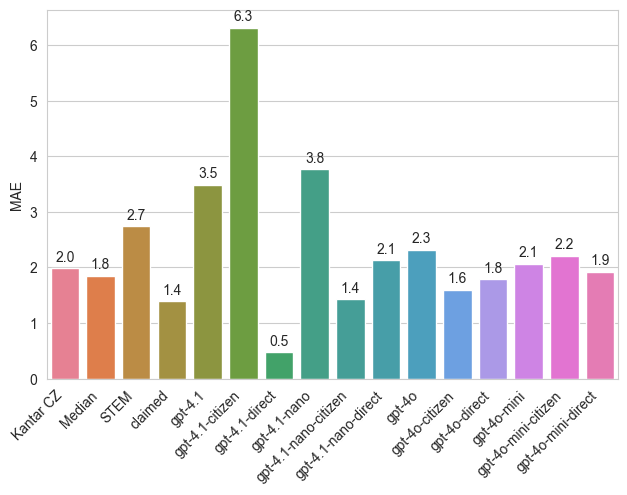

In [104]:
def plot_cesko(tmp_df):
    tmp_df = tmp_df.copy()
    tmp_df['mae'] = 100*tmp_df['mae']
    tmp_df['source'] = tmp_df['source'].astype(str)
    print(tmp_df['source'])

    fig, ax = plt.subplots()
    ax = sns.barplot(ax=ax,
                     data=tmp_df,
                     x='source',
                     y='mae',
                     hue='source',
                     legend=False,
    )
    ax.set_xticks(range(len(tmp_df['source'])))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_xlabel("")
    ax.set_ylabel("MAE")

    # Add value labels on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=3)

    fig.tight_layout()
    plt.subplots_adjust(bottom=0.2)
    plt.show()

plot_cesko(tmp_df)

In [105]:
tmp_df[['source','mae']]

,source,mae
15,Kantar CZ,0.019822
14,Median,0.018444
13,STEM,0.027358
4,claimed,0.013906
1,gpt-4.1,0.034862
6,gpt-4.1-citizen,0.063101
10,gpt-4.1-direct,0.004723
0,gpt-4.1-nano,0.037599
5,gpt-4.1-nano-citizen,0.014234
9,gpt-4.1-nano-direct,0.021284


## other aggregations

In [106]:
from typing import Dict, List, Optional, Sequence, Tuple
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from math import ceil

# Assumes these exist in your project:
# - PARTIES: List[str]
# - drop_both(election_data) -> pd.DataFrame
# - calculate_distances(df1, df2) -> pd.DataFrame
# - sort_df_by_volebni_kraje_population(df, region_first, ascending) -> Tuple[pd.DataFrame, List]

def clean_voted_party_and_report(
    df: pd.DataFrame,
    voted_col: str = "voted_party",
    drop_value: str = "Nechci uvést",
    rename_from: str = "Nebyl/a jsem volit",
    rename_to: str = "Not voted",
) -> Tuple[pd.DataFrame, Dict[str, int]]:
    """Drop rows with `drop_value` and rename `rename_from` -> `rename_to`. Print counts."""
    if voted_col not in df.columns:
        raise ValueError(f"Missing column: {voted_col}")

    df = df.copy()

    # 1) Drop "Nechci uvést"
    mask_drop = df[voted_col] == drop_value
    dropped_count = int(mask_drop.sum())
    df = df.loc[~mask_drop]

    # 2) Rename "Nebyl/a jsem volit" -> "Not voted"
    mask_rename = df[voted_col] == rename_from
    renamed_count = int(mask_rename.sum())
    if renamed_count:
        df.loc[mask_rename, voted_col] = rename_to

    # 3) Report numbers of changes performed
    print(f"Dropped rows where {voted_col} == '{drop_value}': {dropped_count}")
    print(f"Renamed '{rename_from}' -> '{rename_to}': {renamed_count}")

    return df, {"dropped": dropped_count, "renamed": renamed_count}

def add_parties_one_hot(
    df: pd.DataFrame,
    parties: List[str],
    voted_col: str = "voted_party",
) -> pd.DataFrame:
    """Create one-hot party columns from `voted_col` with 0/1 per row for provided `parties`."""
    if voted_col not in df.columns:
        raise ValueError(f"Missing column: {voted_col}")
    df = df.copy()
    for p in parties:
        df[p] = (df[voted_col] == p).astype(int)
    return df

def _prepare_df1(election_data: pd.DataFrame, agg_col: str) -> pd.DataFrame:
    """Prepare ground-truth DataFrame indexed by `agg_col` if present."""
    if election_data is None or election_data.empty:
        raise ValueError("election_data is empty.")
    df1 = drop_both(election_data)
    # If df1 carries `agg_col` as a column, set it as index; else assume already indexed properly.
    if agg_col in df1.columns:
        df1 = df1.set_index(agg_col)
    df1 = df1.sort_index()
    if df1.empty:
        raise ValueError("df1 became empty after preprocessing.")
    return df1

def build_claimed_df2(
    panel_data: pd.DataFrame,
    df1: pd.DataFrame,
    parties: List[str],
    agg_col: str = "region",
    voted_col: str = "voted_party",
    region_first: str = "Česko",
    print_result: bool = True,
) -> pd.DataFrame:
    """
    Build df2 for 'claimed' from panel_data by:
      - cleaning voted_party,
      - one-hot encoding into `parties` columns,
      - printing the resulting dataframe,
      - grouping by `agg_col` and taking mean,
      - appending a total mean row labeled `region_first`,
      - aligning to df1 rows/columns.
    """
    if panel_data is None or panel_data.empty:
        raise ValueError("panel_data is empty.")
    if agg_col not in panel_data.columns:
        raise ValueError(f"Missing aggregation column: {agg_col}")

    cleaned, _stats = clean_voted_party_and_report(panel_data, voted_col=voted_col)
    claimed_ohe = add_parties_one_hot(cleaned, parties=parties, voted_col=voted_col)

    if print_result:
        cols_to_print = [agg_col, voted_col] + list(parties)
        cols_to_print = [c for c in cols_to_print if c in claimed_ohe.columns]
        print("Resulting 'claimed' DataFrame (after one-hot):")
        print(claimed_ohe[cols_to_print])

    df2_group = claimed_ohe.groupby(agg_col)[parties].mean()

    # Add total mean row (e.g., 'Česko')
    mean_df = claimed_ohe[parties].mean().to_frame().T
    mean_df[agg_col] = region_first
    mean_df.set_index(agg_col, inplace=True)

    df2 = (
        pd.concat([df2_group, mean_df])
        .sort_index()
        .reindex(columns=df1.columns, index=df1.index)
    )
    return df2

def _model_colors(models: List[str]) -> Dict[str, str]:
    palette = [
        "#4C72B0", "#55A868", "#C44E52", "#8172B2",
        "#CCB974", "#64B5CD", "#8C8C8C", "#937860",
    ]
    return {m: palette[i % len(palette)] for i, m in enumerate(models)}

def make_distance_figure(
    model_to_metrics: Dict[str, pd.DataFrame],
    region_order: List,
    metrics: List[str],
    region_first: str = "Česko",
    ncols: int = 2,
    height_per_row: int = 350,
    template: str = "plotly_white",
    figure_width: Optional[int] = None,
    col_width: int = 520,
) -> go.Figure:
    n = len(metrics)
    ncols = max(1, int(ncols))
    nrows = ceil(n / ncols)

    fig = make_subplots(
        rows=nrows,
        cols=ncols,
        subplot_titles=[str(m) for m in metrics],
        horizontal_spacing=0.08,
        vertical_spacing=0.12,
    )

    models = list(model_to_metrics.keys())
    colors = _model_colors(models)
    cat_labels = [str(lbl) for lbl in region_order]
    cz_label = next((lbl for lbl in region_order if str(lbl) == region_first), None)
    baseline_model = models[0]

    for i, metric in enumerate(metrics):
        r = i // ncols + 1
        c = i % ncols + 1

        for model in models:
            s = model_to_metrics[model][metric].replace([float("inf"), float("-inf")], pd.NA)
            fig.add_trace(
                go.Scatter(
                    x=cat_labels,
                    y=s.values,
                    mode="lines+markers",
                    name=model,
                    line=dict(width=2, color=colors[model]),
                    hovertemplate=(
                        "Group=%{x}<br>"
                        + f"{metric}: " + "%{y:.6g}<br>"
                        + f"Model={model}<extra></extra>"
                    ),
                    legendgroup=model,
                    showlegend=(i == 0),
                ),
                row=r, col=c,
            )

        if cz_label is not None:
            cz_val = model_to_metrics[baseline_model].loc[cz_label, metric]
            if pd.notna(cz_val):
                fig.add_hline(
                    y=float(cz_val),
                    line_dash="dash",
                    line_color="#C44E52",
                    line_width=1.5,
                    row=r,
                    col=c,
                )

        fig.update_xaxes(
            categoryorder="array",
            categoryarray=cat_labels,
            tickangle=45,
            row=r,
            col=c,
        )
        fig.update_yaxes(title_text="Distance", row=r, col=c)

    total_cells = nrows * ncols
    for j in range(n, total_cells):
        r = j // ncols + 1
        c = j % ncols + 1
        fig.update_xaxes(visible=False, row=r, col=c)
        fig.update_yaxes(visible=False, row=r, col=c)

    width = figure_width if figure_width is not None else max(800, ncols * col_width)
    fig.update_layout(
        height=max(350, nrows * height_per_row),
        width=width,
        title_text="Distance per metric by group (models + claimed)",
        showlegend=True,
        hovermode="x unified",
        template=template,
        legend_title_text="Model",
        margin=dict(l=60, r=20, t=60, b=60),
    )
    return fig

def _order_index_for_plot(
    metrics_df: pd.DataFrame,
    region_first: str,
    agg_col: str,
    ascending_population: bool,
) -> List:
    """
    If aggregating by 'region', use population-based ordering with `region_first`.
    Otherwise, alphabetical order with `region_first` (if present) pinned to the front.
    """
    if agg_col == "region":
        _, region_order = sort_df_by_volebni_kraje_population(
            metrics_df, region_first=region_first, ascending=ascending_population
        )
        return region_order
    # Generic alphabetical ordering
    idx = list(metrics_df.index)
    if region_first in idx:
        idx.remove(region_first)
        return [region_first] + sorted(idx)
    return sorted(idx)

def plot_distance_lines_from_voting_results(
    election_data: pd.DataFrame,
    panel_data: pd.DataFrame,
    voting_results_dict: Dict[str, pd.DataFrame],
    models: Optional[List[str]] = None,
    parties: Optional[List[str]] = None,
    agg_col: str = "region",              # <- new: choose aggregation column
    region_first: str = "Česko",          # label put first in order (and used for total row)
    ncols: int = 2,
    height_per_row: int = 350,
    template: str = "plotly_white",
    ascending_population: bool = False,
    figure_width: Optional[int] = None,
    col_width: int = 520,
    distances: Optional[Sequence[str]] = None,
    include_claimed: bool = True,
) -> go.Figure:
    """Compute per-model (and optional 'claimed') distances aggregated by `agg_col` and plot."""
    if parties is None:
        if "PARTIES" not in globals():
            raise ValueError("PARTIES must be provided or defined globally.")
        parties = PARTIES

    # Ground truth, indexed by agg_col if present
    df1 = _prepare_df1(election_data, agg_col=agg_col)

    # Determine models
    models = list(voting_results_dict.keys()) if not models else models

    model_to_metrics: Dict[str, pd.DataFrame] = {}
    region_order: Optional[List] = None
    metrics_names: Optional[List[str]] = None

    # Add model-based metrics
    for model in models:
        if model not in voting_results_dict:
            continue

        vr = voting_results_dict[model]

        # Aggregate joined panel + model results by agg_col
        df2_group = panel_data.join(vr).groupby(agg_col)[parties].mean()

        # Add total mean row (region_first)
        mean_df = vr[parties].mean().to_frame().T
        mean_df[agg_col] = region_first
        mean_df.set_index(agg_col, inplace=True)

        df2 = (
            pd.concat([df2_group, mean_df])
            .sort_index()
            .reindex(columns=df1.columns, index=df1.index)
        )

        metrics_df = calculate_distances(df1, df2)

        if region_order is None:
            region_order = _order_index_for_plot(
                metrics_df, region_first=region_first, agg_col=agg_col, ascending_population=ascending_population
            )
            metrics_names = list(metrics_df.select_dtypes(include="number").columns)

        model_to_metrics[model] = metrics_df.reindex(region_order)

    # Add claimed-based metrics
    if include_claimed:
        df2_claimed = build_claimed_df2(
            panel_data=panel_data,
            df1=df1,
            parties=parties,
            agg_col=agg_col,
            voted_col="voted_party",
            region_first=region_first,
            print_result=True,
        )
        metrics_claimed = calculate_distances(df1, df2_claimed)

        if region_order is None:
            region_order = _order_index_for_plot(
                metrics_claimed, region_first=region_first, agg_col=agg_col, ascending_population=ascending_population
            )
            metrics_names = list(metrics_claimed.select_dtypes(include="number").columns)

        model_to_metrics["claimed"] = metrics_claimed.reindex(region_order)

    if not model_to_metrics:
        raise ValueError("No metrics computed. Provide at least one model or set include_claimed=True.")
    if not metrics_names:
        any_metrics_df = next(iter(model_to_metrics.values()))
        metrics_names = list(any_metrics_df.select_dtypes(include="number").columns)
    if distances:
        requested = {str(d) for d in distances}
        selected = [m for m in metrics_names if str(m) in requested]
        if not selected:
            raise ValueError(f"No requested distances matched. Available: {metrics_names}")
        metrics_names = selected

    return make_distance_figure(
        model_to_metrics=model_to_metrics,
        region_order=region_order,
        metrics=metrics_names,
        region_first=region_first,
        ncols=ncols,
        height_per_row=height_per_row,
        template=template,
        figure_width=figure_width,
        col_width=col_width,
    )

# Summary statistics

<>:20: SyntaxWarning: invalid escape sequence '\_'
<>:20: SyntaxWarning: invalid escape sequence '\_'
C:\Users\Martin\AppData\Local\Temp\ipykernel_92044\2360417348.py:20: SyntaxWarning: invalid escape sequence '\_'
  """


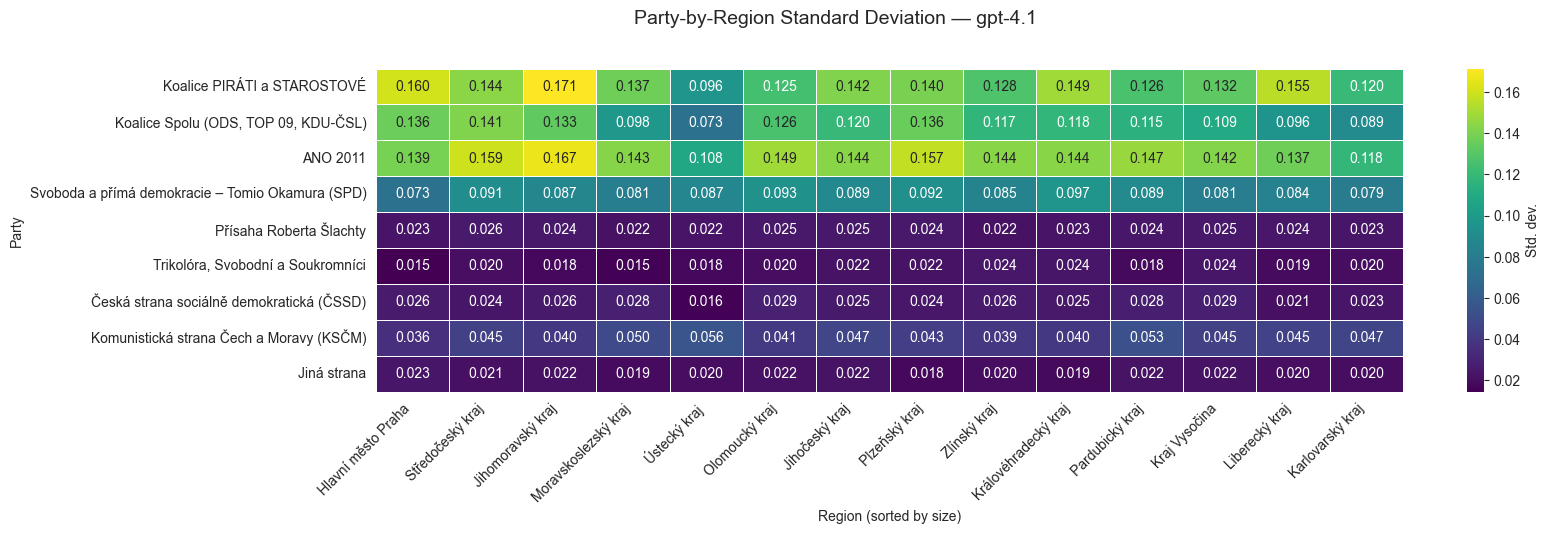

(<Figure size 1680x540 with 2 Axes>,
 region                                            Hlavní město Praha  \
 party                                                                  
 Koalice PIRÁTI a STAROSTOVÉ                                 0.160480   
 Koalice Spolu (ODS, TOP 09, KDU-ČSL)                        0.136230   
 ANO 2011                                                    0.139138   
 Svoboda a přímá demokracie – Tomio Okamura (SPD)            0.073161   
 Přísaha Roberta Šlachty                                     0.022621   
 Trikolóra, Svobodní a Soukromníci                           0.014501   
 Česká strana sociálně demokratická (ČSSD)                   0.025974   
 Komunistická strana Čech a Moravy (KSČM)                    0.035572   
 Jiná strana                                                 0.023160   
 
 region                                            Středočeský kraj  \
 party                                                                
 Koalice PIRÁTI 

In [107]:
# python
from typing import Dict, Optional, Sequence, Tuple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def party_region_std_heatmap(
    panel_data: pd.DataFrame,
    voting_results_dict: Dict[str, pd.DataFrame],
    parties: Optional[Sequence[str]] = None,
    model_key: str = "gpt-4o-mini",
    region_col: str = "region",
    ddof: int = 1,
    width_per_region: float = 1.2,
    height_per_party: float = 0.6,
    cmap: str = "viridis",
    show: bool = True,
) -> Tuple[plt.Figure, pd.DataFrame]:
    """
    Compute std\_dev of each party by region (rows=parties, cols=regions), drop party `Not Voted`,
    sort regions by size (largest first), and display as a heatmap. Returns (fig, matrix).
    """
    if model_key not in voting_results_dict:
        raise ValueError(f"Model `{model_key}` not found in voting_results_dict.")
    vr = voting_results_dict[model_key]
    merged = panel_data.join(vr, how="left")

    if region_col not in merged.columns:
        raise ValueError(f"Region column `{region_col}` not found in merged data.")

    # determine party columns
    if parties is None:
        parties = [c for c in vr.columns if pd.api.types.is_numeric_dtype(vr[c])]
    parties = [p for p in parties if p in merged.columns]

    # drop 'Not Voted' party if present
    parties = [p for p in parties if str(p).strip().lower() != "not voted"]

    if not parties:
        raise ValueError("No party columns found to compute standard deviation (after dropping `Not Voted`).")

    # compute std grouped by party and region
    long = (
        merged[[region_col] + list(parties)]
        .melt(id_vars=region_col, value_vars=list(parties), var_name="party", value_name="value")
        .dropna(subset=["value"])
    )

    # grouped std
    grp = long.groupby(["party", region_col])["value"].agg(lambda x: x.std(ddof=ddof))
    matrix = grp.unstack(level=region_col)

    # ensure all parties present and sort regions by size (largest to smallest)
    region_counts = merged[region_col].dropna().value_counts()
    regions_sorted = region_counts.index.tolist()
    matrix = matrix.reindex(index=parties, columns=regions_sorted)

    # plotting
    n_rows, n_cols = len(parties), len(regions_sorted)
    fig_width = max(6, n_cols * width_per_region)
    fig_height = max(2, n_rows * height_per_party)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    mask = matrix.isna()
    sns.heatmap(
        matrix,
        ax=ax,
        mask=mask,
        cmap=cmap,
        annot=True,
        fmt=".3f",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Std. dev."},
        square=False,
    )

    ax.set_xlabel("Region (sorted by size)")
    ax.set_ylabel("Party")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    fig.suptitle(f"Party-by-Region Standard Deviation — {model_key}", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    if show:
        plt.show()

    return fig, matrix

party_region_std_heatmap(panel_data, voting_results_dict, model_key='gpt-4.1')

C:\Users\Martin\AppData\Local\Temp\ipykernel_92044\1514244762.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 0.96])


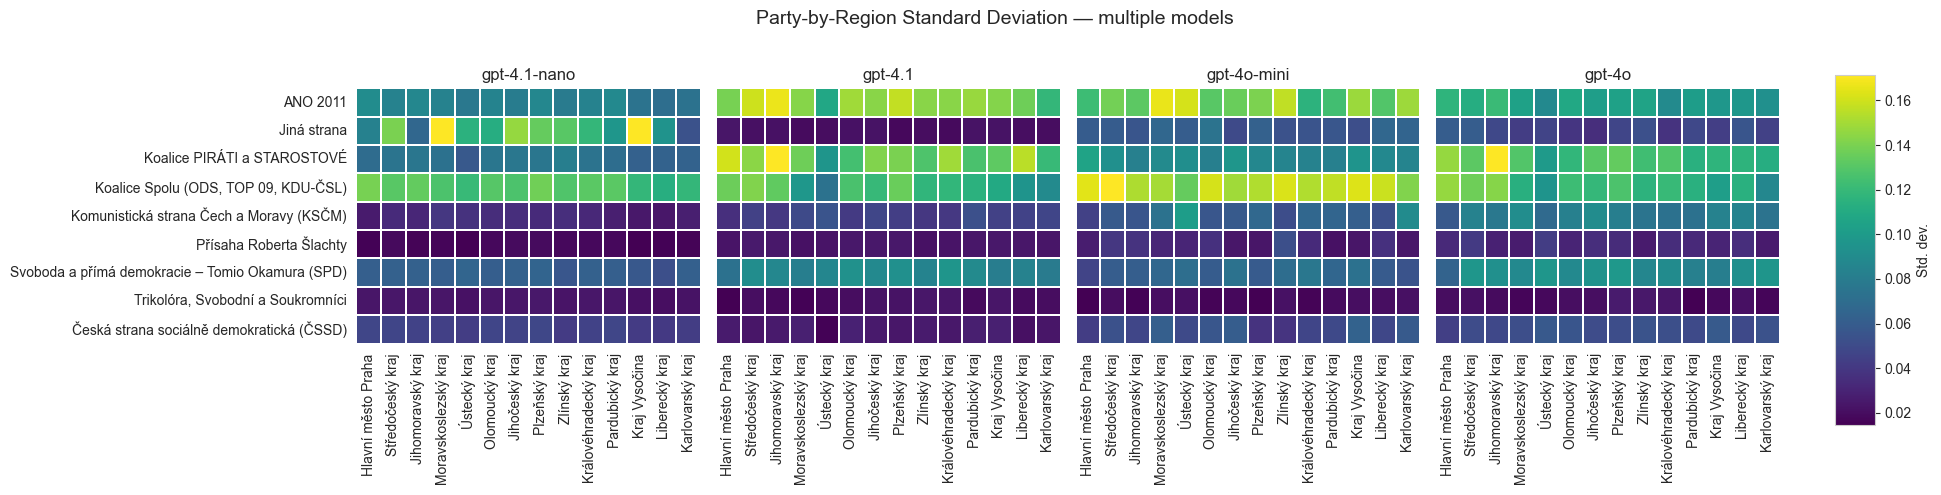

(<Figure size 2000x500 with 5 Axes>,
 {'gpt-4.1-nano': region                                            Hlavní město Praha  \
  party                                                                  
  ANO 2011                                                    0.089582   
  Jiná strana                                                 0.082485   
  Koalice PIRÁTI a STAROSTOVÉ                                 0.069294   
  Koalice Spolu (ODS, TOP 09, KDU-ČSL)                        0.137369   
  Komunistická strana Čech a Moravy (KSČM)                    0.026309   
  Přísaha Roberta Šlachty                                     0.015960   
  Svoboda a přímá demokracie – Tomio Okamura (SPD)            0.061123   
  Trikolóra, Svobodní a Soukromníci                           0.023965   
  Česká strana sociálně demokratická (ČSSD)                   0.047096   
  
  region                                            Středočeský kraj  \
  party                                                   

In [108]:
from typing import Dict, Optional, Sequence, Tuple, List
from math import ceil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def heatmap_grid_of_std_matrices(
    panel_data: pd.DataFrame,
    voting_results_dict: Dict[str, pd.DataFrame],
    model_keys: Optional[Sequence[str]] = None,
    grid_shape: Tuple[int, int] = (4, 4),
    parties: Optional[Sequence[str]] = None,
    region_col: str = "region",
    ddof: int = 1,
    per_subplot_size: Tuple[float, float] = (4.0, 3.0),
    cmap: str = "viridis",
    annot: bool = False,
    fmt: str = ".3f",
    show: bool = True,
) -> Tuple[plt.Figure, Dict[str, pd.DataFrame]]:
    """
    Create a grid of heatmaps for party-by-region std. dev. matrices.
    - Does NOT pad models to fill the grid; uses only available models (up to grid_size).
    - Grid is compact: cols = min(requested_cols, n_models), rows = ceil(n_models / cols).
    Returns (fig, matrices_dict).
    """
    if region_col not in panel_data.columns:
        raise ValueError(f"Region column `{region_col}` not found in `panel_data`.")
    all_model_keys = list(voting_results_dict.keys())
    if not all_model_keys:
        raise ValueError("`voting_results_dict` is empty.")

    max_rows, max_cols = grid_shape
    grid_size = max_rows * max_cols

    # pick model keys (don't pad)
    if model_keys is None:
        chosen = all_model_keys[:grid_size]
    else:
        chosen = [k for k in model_keys if k in voting_results_dict][:grid_size]
        if not chosen:
            raise ValueError("None of the provided `model_keys` exist in `voting_results_dict`.")

    n_models = len(chosen)
    # compact layout: limit cols to requested max and number of models
    cols = min(max_cols, n_models) if n_models > 0 else 1
    rows = max(1, ceil(n_models / cols))

    # determine global region ordering
    region_counts = panel_data[region_col].dropna().value_counts()
    regions_sorted: List = region_counts.index.tolist()

    # determine parties
    if parties is None:
        party_set = set()
        for k in chosen:
            vr = voting_results_dict[k]
            numeric_cols = [c for c in vr.columns if pd.api.types.is_numeric_dtype(vr[c])]
            party_set.update(numeric_cols)
        parties_list = sorted(party_set)
    else:
        parties_list = [p for p in parties]

    # drop Not Voted
    parties_list = [p for p in parties_list if str(p).strip().lower() != "not voted"]
    if not parties_list:
        raise ValueError("No party columns to plot after dropping `Not Voted`.")

    matrices: Dict[str, pd.DataFrame] = {}
    for key in chosen:
        vr = voting_results_dict[key]
        merged = panel_data.join(vr, how="left")
        existing_parties = [p for p in parties_list if p in merged.columns]
        if not existing_parties:
            mat = pd.DataFrame(index=parties_list, columns=regions_sorted, dtype=float)
            matrices[key] = mat
            continue
        long = (
            merged[[region_col] + existing_parties]
            .melt(id_vars=region_col, value_vars=existing_parties, var_name="party", value_name="value")
            .dropna(subset=["value"])
        )
        if long.empty:
            mat = pd.DataFrame(index=existing_parties, columns=regions_sorted, dtype=float)
            matrices[key] = mat.reindex(index=parties_list, columns=regions_sorted)
            continue
        grp = long.groupby(["party", region_col])["value"].agg(lambda x: x.std(ddof=ddof))
        mat = grp.unstack(level=region_col)
        mat = mat.reindex(index=parties_list, columns=regions_sorted)
        matrices[key] = mat

    # figure and axes
    subplot_w, subplot_h = per_subplot_size
    fig_w = cols * subplot_w
    fig_h = rows * subplot_h
    fig, axes = plt.subplots(rows, cols, figsize=(fig_w, fig_h), squeeze=False)

    for idx, key in enumerate(chosen):
        r = idx // cols
        c = idx % cols
        ax = axes[r][c]
        mat = matrices[key]
        if mat.isna().all().all():
            ax.text(0.5, 0.5, "no data", ha="center", va="center")
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(str(key))
            continue
        mask = mat.isna()
        sns.heatmap(
            mat,
            ax=ax,
            mask=mask,
            cmap=cmap,
            annot=annot,
            fmt=fmt,
            cbar=False,
            linewidths=0.3,
            linecolor="white",
            xticklabels=True,
            yticklabels=True,
        )
        ax.set_title(str(key))
        ax.set_xlabel("")
        ax.set_ylabel("")
        if c != 0:
            ax.set_yticklabels([])
        if r != rows - 1:
            ax.set_xticklabels([])

    # hide any leftover/unused axes
    total_axes = rows * cols
    for extra_idx in range(n_models, total_axes):
        r = extra_idx // cols
        c = extra_idx % cols
        ax = axes[r][c]
        ax.axis("off")

    # single shared colorbar based on available matrices
    combined = pd.concat([m.stack() for k, m in matrices.items() if not m.empty and not m.isna().all().all()], axis=0)
    if not combined.empty:
        vmin = combined.min()
        vmax = combined.max()
    else:
        vmin, vmax = 0.0, 1.0
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, label="Std. dev.")

    fig.suptitle("Party-by-Region Standard Deviation — multiple models", fontsize=14)
    fig.tight_layout(rect=[0, 0, 0.9, 0.96])

    if show:
        plt.show()

    return fig, matrices

heatmap_grid_of_std_matrices(panel_data, voting_results_dict, per_subplot_size=(5,5))

a# Sandbox

In [109]:
panel_data['voted_party'].value_counts(normalize=True)

voted_party
Koalice Spolu (ODS, TOP 09, KDU-ČSL)                0.176804
Nechci uvést                                        0.171134
Nebyl/a jsem volit                                  0.167784
ANO 2011                                            0.165464
Koalice PIRÁTI a STAROSTOVÉ                         0.128351
Svoboda a přímá demokracie – Tomio Okamura (SPD)    0.053093
Nevím                                               0.043299
Česká strana sociálně demokratická (ČSSD)           0.030412
Jiná strana                                         0.019330
Přísaha Roberta Šlachty                             0.017784
Trikolóra, Svobodní a Soukromníci                   0.013918
Komunistická strana Čech a Moravy (KSČM)            0.012629
Name: proportion, dtype: float64

In [110]:
print(voting_results_dict['gpt-4.1'].columns)

Index(['Koalice PIRÁTI a STAROSTOVÉ', 'Koalice Spolu (ODS, TOP 09, KDU-ČSL)',
       'ANO 2011', 'Svoboda a přímá demokracie – Tomio Okamura (SPD)',
       'Přísaha Roberta Šlachty', 'Trikolóra, Svobodní a Soukromníci',
       'Česká strana sociálně demokratická (ČSSD)',
       'Komunistická strana Čech a Moravy (KSČM)', 'Jiná strana'],
      dtype='object')


In [111]:
voting_results_dict['gpt-4.1']

,Koalice PIRÁTI a STAROSTOVÉ,"Koalice Spolu (ODS, TOP 09, KDU-ČSL)",ANO 2011,Svoboda a přímá demokracie – Tomio Okamura (SPD),Přísaha Roberta Šlachty,"Trikolóra, Svobodní a Soukromníci",Česká strana sociálně demokratická (ČSSD),Komunistická strana Čech a Moravy (KSČM),Jiná strana
0,0.45,0.30,0.10,0.03,0.05,0.02,0.02,0.01,0.02
1,0.45,0.30,0.10,0.05,0.03,0.02,0.02,0.01,0.02
2,0.05,0.10,0.45,0.25,0.08,0.04,0.00,0.02,0.01
3,0.05,0.10,0.45,0.25,0.08,0.04,0.01,0.02,0.00
4,0.10,0.08,0.45,0.25,0.07,0.00,0.00,0.00,0.05
...,...,...,...,...,...,...,...,...,...
3875,0.28,0.32,0.22,0.07,0.04,0.02,0.03,0.01,0.01
3876,0.55,0.25,0.08,0.02,0.01,0.01,0.03,0.00,0.05
3877,0.22,0.18,0.35,0.10,0.03,0.00,0.05,0.05,0.02
3878,0.45,0.12,0.18,0.08,0.04,0.00,0.10,0.00,0.03


In [112]:
voting_results_dict['gpt-4.1'][voting_results_dict['gpt-4.1'].sum(axis=1) != 1.0]#.sum(axis=1)

,Koalice PIRÁTI a STAROSTOVÉ,"Koalice Spolu (ODS, TOP 09, KDU-ČSL)",ANO 2011,Svoboda a přímá demokracie – Tomio Okamura (SPD),Přísaha Roberta Šlachty,"Trikolóra, Svobodní a Soukromníci",Česká strana sociálně demokratická (ČSSD),Komunistická strana Čech a Moravy (KSČM),Jiná strana
8,0.55,0.30,0.07,0.02,0.005,0.010,0.005,0.005,0.04
9,0.38,0.28,0.15,0.07,0.050,0.020,0.030,0.010,0.01
11,0.35,0.45,0.10,0.03,0.005,0.010,0.005,0.005,0.05
17,0.05,0.10,0.55,0.20,0.030,0.020,0.010,0.040,0.00
28,0.03,0.02,0.55,0.25,0.020,0.020,0.010,0.100,0.00
...,...,...,...,...,...,...,...,...,...
3870,0.28,0.18,0.22,0.13,0.030,0.030,0.060,0.050,0.02
3872,0.35,0.25,0.18,0.05,0.040,0.030,0.070,0.020,0.01
3873,0.45,0.35,0.10,0.03,0.005,0.005,0.010,0.005,0.05
3875,0.28,0.32,0.22,0.07,0.040,0.020,0.030,0.010,0.01


In [113]:
people_df = pd.read_csv(os.path.join(DATA_DIR, "clean_data.csv"), index_col=0)
people_df

,gender,age,education_level,region,district,town_size,employment_status,income_range,living_standard,interest_in_politics,voted_party
0,muž,28,vysokoškolské vzdělání,Středočeský kraj,Nymburk,Méně než 1.000 obyvatel,zaměstnanec na plný úvazek,30.001 - 40.000 Kč,spíše dobrou,velmi se zajímám,Koalice PIRÁTI a STAROSTOVÉ
1,muž,27,vysokoškolské vzdělání,Plzeňský kraj,Plzeň-město,Více než 100.000 obyvatel,zaměstnanec na plný úvazek,20.001 - 25.000 Kč,spíše dobrou,spíše se zajímám,Koalice PIRÁTI a STAROSTOVÉ
2,žena,33,základní + středoškolské vzdělání bez maturity,Královéhradecký kraj,Jičín,Méně než 1.000 obyvatel,zaměstnanec na plný úvazek,25.001 - 30.000 Kč,"ani dobrou, ani špatnou",spíše se zajímám,ANO 2011
3,žena,27,základní + středoškolské vzdělání bez maturity,Plzeňský kraj,Rokycany,20.001 - 100.000 obyvatel,zaměstnanec na plný úvazek,20.001 - 25.000 Kč,spíše dobrou,spíše se zajímám,Nechci uvést
4,muž,21,středoškolské vzdělání s maturitou,Ústecký kraj,Chomutov,20.001 - 100.000 obyvatel,zaměstnanec na plný úvazek,30.001 - 40.000 Kč,velmi dobrou,vůbec se nezajímám,Jiná strana
...,...,...,...,...,...,...,...,...,...,...,...
3875,žena,39,středoškolské vzdělání s maturitou,Plzeňský kraj,Plzeň-město,Více než 100.000 obyvatel,zaměstnanec na plný úvazek,40.001 - 60.000 Kč,spíše dobrou,spíše se nezajímám,ANO 2011
3876,žena,30,vysokoškolské vzdělání,Hlavní město Praha,Praha,Více než 100.000 obyvatel,zaměstnanec na částečný úvazek,NaN,spíše dobrou,spíše se zajímám,Koalice PIRÁTI a STAROSTOVÉ
3877,žena,47,vysokoškolské vzdělání,Moravskoslezský kraj,Karviná,5.001 - 20.000 obyvatel,zaměstnanec na plný úvazek,40.001 - 60.000 Kč,spíše dobrou,vůbec se nezajímám,Nechci uvést
3878,žena,23,středoškolské vzdělání s maturitou,Hlavní město Praha,Praha,20.001 - 100.000 obyvatel,zaměstnanec na plný úvazek,20.001 - 25.000 Kč,spíše špatnou,nevím,Nechci uvést


In [114]:
voting_results_dict['gpt-4.1']

,Koalice PIRÁTI a STAROSTOVÉ,"Koalice Spolu (ODS, TOP 09, KDU-ČSL)",ANO 2011,Svoboda a přímá demokracie – Tomio Okamura (SPD),Přísaha Roberta Šlachty,"Trikolóra, Svobodní a Soukromníci",Česká strana sociálně demokratická (ČSSD),Komunistická strana Čech a Moravy (KSČM),Jiná strana
0,0.45,0.30,0.10,0.03,0.05,0.02,0.02,0.01,0.02
1,0.45,0.30,0.10,0.05,0.03,0.02,0.02,0.01,0.02
2,0.05,0.10,0.45,0.25,0.08,0.04,0.00,0.02,0.01
3,0.05,0.10,0.45,0.25,0.08,0.04,0.01,0.02,0.00
4,0.10,0.08,0.45,0.25,0.07,0.00,0.00,0.00,0.05
...,...,...,...,...,...,...,...,...,...
3875,0.28,0.32,0.22,0.07,0.04,0.02,0.03,0.01,0.01
3876,0.55,0.25,0.08,0.02,0.01,0.01,0.03,0.00,0.05
3877,0.22,0.18,0.35,0.10,0.03,0.00,0.05,0.05,0.02
3878,0.45,0.12,0.18,0.08,0.04,0.00,0.10,0.00,0.03


In [115]:
people_df.join(voting_results_dict['gpt-4.1'])

,gender,age,education_level,region,district,town_size,employment_status,income_range,living_standard,interest_in_politics,voted_party,Koalice PIRÁTI a STAROSTOVÉ,"Koalice Spolu (ODS, TOP 09, KDU-ČSL)",ANO 2011,Svoboda a přímá demokracie – Tomio Okamura (SPD),Přísaha Roberta Šlachty,"Trikolóra, Svobodní a Soukromníci",Česká strana sociálně demokratická (ČSSD),Komunistická strana Čech a Moravy (KSČM),Jiná strana
0,muž,28,vysokoškolské vzdělání,Středočeský kraj,Nymburk,Méně než 1.000 obyvatel,zaměstnanec na plný úvazek,30.001 - 40.000 Kč,spíše dobrou,velmi se zajímám,Koalice PIRÁTI a STAROSTOVÉ,0.45,0.30,0.10,0.03,0.05,0.02,0.02,0.01,0.02
1,muž,27,vysokoškolské vzdělání,Plzeňský kraj,Plzeň-město,Více než 100.000 obyvatel,zaměstnanec na plný úvazek,20.001 - 25.000 Kč,spíše dobrou,spíše se zajímám,Koalice PIRÁTI a STAROSTOVÉ,0.45,0.30,0.10,0.05,0.03,0.02,0.02,0.01,0.02
2,žena,33,základní + středoškolské vzdělání bez maturity,Královéhradecký kraj,Jičín,Méně než 1.000 obyvatel,zaměstnanec na plný úvazek,25.001 - 30.000 Kč,"ani dobrou, ani špatnou",spíše se zajímám,ANO 2011,0.05,0.10,0.45,0.25,0.08,0.04,0.00,0.02,0.01
3,žena,27,základní + středoškolské vzdělání bez maturity,Plzeňský kraj,Rokycany,20.001 - 100.000 obyvatel,zaměstnanec na plný úvazek,20.001 - 25.000 Kč,spíše dobrou,spíše se zajímám,Nechci uvést,0.05,0.10,0.45,0.25,0.08,0.04,0.01,0.02,0.00
4,muž,21,středoškolské vzdělání s maturitou,Ústecký kraj,Chomutov,20.001 - 100.000 obyvatel,zaměstnanec na plný úvazek,30.001 - 40.000 Kč,velmi dobrou,vůbec se nezajímám,Jiná strana,0.10,0.08,0.45,0.25,0.07,0.00,0.00,0.00,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3875,žena,39,středoškolské vzdělání s maturitou,Plzeňský kraj,Plzeň-město,Více než 100.000 obyvatel,zaměstnanec na plný úvazek,40.001 - 60.000 Kč,spíše dobrou,spíše se nezajímám,ANO 2011,0.28,0.32,0.22,0.07,0.04,0.02,0.03,0.01,0.01
3876,žena,30,vysokoškolské vzdělání,Hlavní město Praha,Praha,Více než 100.000 obyvatel,zaměstnanec na částečný úvazek,NaN,spíše dobrou,spíše se zajímám,Koalice PIRÁTI a STAROSTOVÉ,0.55,0.25,0.08,0.02,0.01,0.01,0.03,0.00,0.05
3877,žena,47,vysokoškolské vzdělání,Moravskoslezský kraj,Karviná,5.001 - 20.000 obyvatel,zaměstnanec na plný úvazek,40.001 - 60.000 Kč,spíše dobrou,vůbec se nezajímám,Nechci uvést,0.22,0.18,0.35,0.10,0.03,0.00,0.05,0.05,0.02
3878,žena,23,středoškolské vzdělání s maturitou,Hlavní město Praha,Praha,20.001 - 100.000 obyvatel,zaměstnanec na plný úvazek,20.001 - 25.000 Kč,spíše špatnou,nevím,Nechci uvést,0.45,0.12,0.18,0.08,0.04,0.00,0.10,0.00,0.03


In [116]:
parties = [c for c in voting_results_dict['gpt-4.1'].columns if c not in [VOTED, NOT_VOTED]]
people_df.join(voting_results_dict['gpt-4.1']).groupby('region')[parties].mean()

,Koalice PIRÁTI a STAROSTOVÉ,"Koalice Spolu (ODS, TOP 09, KDU-ČSL)",ANO 2011,Svoboda a přímá demokracie – Tomio Okamura (SPD),Přísaha Roberta Šlachty,"Trikolóra, Svobodní a Soukromníci",Česká strana sociálně demokratická (ČSSD),Komunistická strana Čech a Moravy (KSČM),Jiná strana
region,,,,,,,,,
Hlavní město Praha,0.328312,0.287706,0.197064,0.070138,0.023769,0.013556,0.026268,0.021402,0.032615
Jihomoravský kraj,0.202440,0.221808,0.318693,0.120370,0.035466,0.018139,0.025098,0.033834,0.024532
Jihočeský kraj,0.137864,0.163455,0.377818,0.165773,0.043291,0.023005,0.021750,0.046864,0.020773
Karlovarský kraj,0.105446,0.103267,0.432475,0.201683,0.040000,0.018416,0.017376,0.064208,0.017673
Kraj Vysočina,0.123778,0.166556,0.382500,0.165667,0.043761,0.023211,0.023778,0.050583,0.020194
Královéhradecký kraj,0.150430,0.187392,0.353495,0.155484,0.045618,0.027688,0.020995,0.039489,0.019704
Liberecký kraj,0.160000,0.137742,0.371613,0.166000,0.050129,0.022419,0.018387,0.052452,0.021290
Moravskoslezský kraj,0.144289,0.135963,0.407500,0.161101,0.033078,0.016406,0.027936,0.056617,0.017305
Olomoucký kraj,0.123450,0.158079,0.393930,0.172052,0.036808,0.018507,0.026563,0.049389,0.021507


In [117]:
# Load CSV files into DataFrames
csv_dir = DATA_DIR
claimed_votes_df = pd.read_csv(os.path.join(RESULTS_DIR, "claimed_votes.csv"), index_col=0).squeeze()

cov_matrix_gpt_4_1_nano = pd.read_csv(os.path.join(RESULTS_DIR, "cov_matrix_gpt-4.1-nano_VotingProbabilities.csv"))
cov_matrix_gpt_4_1 = pd.read_csv(os.path.join(RESULTS_DIR, "cov_matrix_gpt-4.1_VotingProbabilities.csv"))
cov_matrix_gpt_4o_mini = pd.read_csv(os.path.join(RESULTS_DIR, "cov_matrix_gpt-4o-mini_VotingProbabilities.csv"))
cov_matrix_gpt_4o = pd.read_csv(os.path.join(RESULTS_DIR, "cov_matrix_gpt-4o_VotingProbabilities.csv"))

election_data = pd.read_csv(os.path.join(DATA_DIR, "election_data.csv"))

regional_pairwise_mae_gpt_4_1_nano = pd.read_csv(os.path.join(RESULTS_DIR, "regional_pairwise_mae_t=0_gpt-4.1-nano_VotingProbabilities.csv"))
regional_pairwise_mae_gpt_4_1 = pd.read_csv(os.path.join(RESULTS_DIR, "regional_pairwise_mae_t=0_gpt-4.1_VotingProbabilities.csv"))
regional_pairwise_mae_gpt_4o = pd.read_csv(os.path.join(RESULTS_DIR, "regional_pairwise_mae_t=0_gpt-4o_VotingProbabilities.csv"))
regional_pairwise_mae_gpt_4o_mini = pd.read_csv(os.path.join(RESULTS_DIR, "regional_pairwise_mae_t=0_gpt-4o-mini_VotingProbabilities.csv"))

voting_results_gpt_4_1 = (pd.read_csv(os.path.join(RESULTS_DIR, f"voting_results_{create_parameter_description(OpenAIClient, GPT_41, VotingProbabilities, 3880, 0.0)}.csv"))).pipe(lambda d: d.loc[:, ~d.columns.str.startswith('Unnamed')].drop(columns=[PROMPT], errors='ignore'))
voting_results_gpt_4_1_nano = (pd.read_csv(os.path.join(RESULTS_DIR, f"voting_results_{create_parameter_description(OpenAIClient, GPT_41_NANO, VotingProbabilities, 3880, 0.0)}.csv"))).pipe(lambda d: d.loc[:, ~d.columns.str.startswith('Unnamed')].drop(columns=[PROMPT], errors='ignore'))
voting_results_gpt_4o = (pd.read_csv(os.path.join(RESULTS_DIR, f"voting_results_{create_parameter_description(OpenAIClient, GPT_4o, VotingProbabilities, 3880, 0.0)}.csv"))).pipe(lambda d: d.loc[:, ~d.columns.str.startswith('Unnamed')].drop(columns=[PROMPT], errors='ignore'))
voting_results_gpt_4o_mini = (pd.read_csv(os.path.join(RESULTS_DIR, f"voting_results_{create_parameter_description(OpenAIClient, GPT_4o_MINI, VotingProbabilities, 3880, 0.0)}.csv"))).pipe(lambda d: d.loc[:, ~d.columns.str.startswith('Unnamed')].drop(columns=[PROMPT], errors='ignore'))


# Create a dictionary with model names as keys and voting result DataFrames as values
voting_results_dict = {
    "gpt_4_1": voting_results_gpt_4_1,
    "gpt_4_1_nano": voting_results_gpt_4_1_nano,
    "gpt_4o": voting_results_gpt_4o,
    "gpt_4o_mini": voting_results_gpt_4o_mini
}

# Display the dictionary keys to verify
print(voting_results_dict.keys())

dict_keys(['gpt_4_1', 'gpt_4_1_nano', 'gpt_4o', 'gpt_4o_mini'])


In [118]:
election_averages_df = election_data[election_data.region == COUNTRY].transpose().drop('region').reset_index()
election_averages_df.columns = ['party', 'average']
election_averages_df = election_averages_df.set_index('party')
# election_averages_df = election_averages_df.drop(index=['Voted'])

print(election_averages_df.sum())

# Display the resulting DataFrame
election_averages_df

average    2.0
dtype: object


,average
party,
Voted,0.6543
Not Voted,0.3457
ANO 2011,0.2712
"Koalice Spolu (ODS, TOP 09, KDU-ČSL)",0.2779
Koalice PIRÁTI a STAROSTOVÉ,0.1562
Komunistická strana Čech a Moravy (KSČM),0.036
Svoboda a přímá demokracie – Tomio Okamura (SPD),0.0956
Česká strana sociálně demokratická (ČSSD),0.0465
"Trikolóra, Svobodní a Soukromníci",0.0276


In [119]:
voting_avgs_df = voting_results_gpt_4_1.mean().drop(index=[VOTED])
print(voting_avgs_df.sum())

voting_avgs_df

1.1359167525773197


Not Voted                                           0.135595
Koalice PIRÁTI a STAROSTOVÉ                         0.168433
Koalice Spolu (ODS, TOP 09, KDU-ČSL)                0.182004
ANO 2011                                            0.354291
Svoboda a přímá demokracie – Tomio Okamura (SPD)    0.149287
Přísaha Roberta Šlachty                             0.038327
Trikolóra, Svobodní a Soukromníci                   0.019236
Česká strana sociálně demokratická (ČSSD)           0.022245
Komunistická strana Čech a Moravy (KSČM)            0.044096
Jiná strana                                         0.022402
dtype: float64

In [120]:
claimed_votes = claimed_votes_df.drop(index=[VOTED])
print(claimed_votes.sum())
claimed_votes

1.2135826771653537


Not Voted                                           0.213583
ANO 2011                                            0.267835
Koalice Spolu (ODS, TOP 09, KDU-ČSL)                0.286191
Koalice PIRÁTI a STAROSTOVÉ                         0.207760
Svoboda a přímá demokracie – Tomio Okamura (SPD)    0.085941
Přísaha Roberta Šlachty                             0.028786
Česká strana sociálně demokratická (ČSSD)           0.049228
Komunistická strana Čech a Moravy (KSČM)            0.020442
Trikolóra, Svobodní a Soukromníci                   0.022528
Jiná strana                                         0.031289
Name: 0, dtype: float64

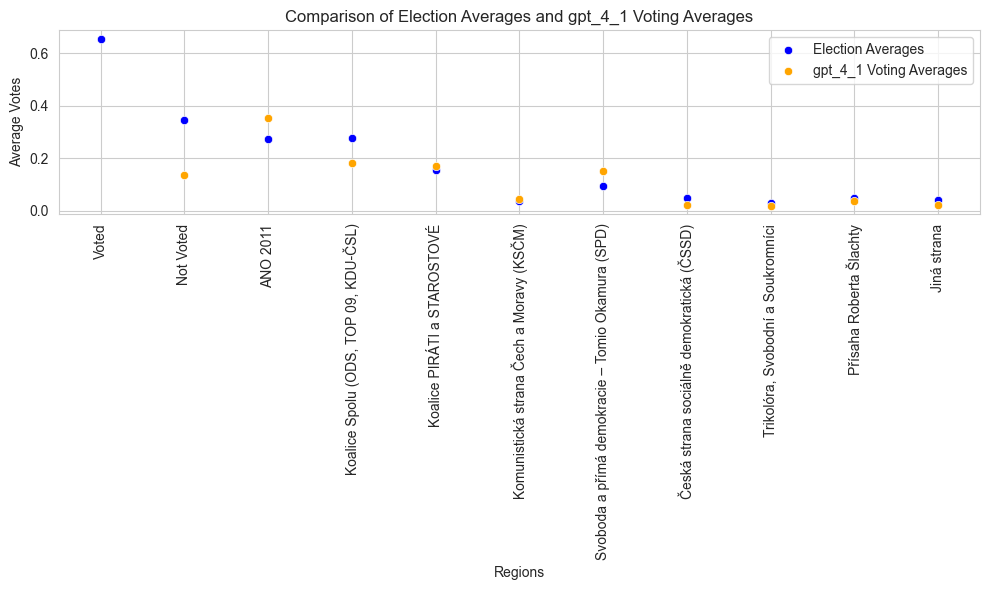

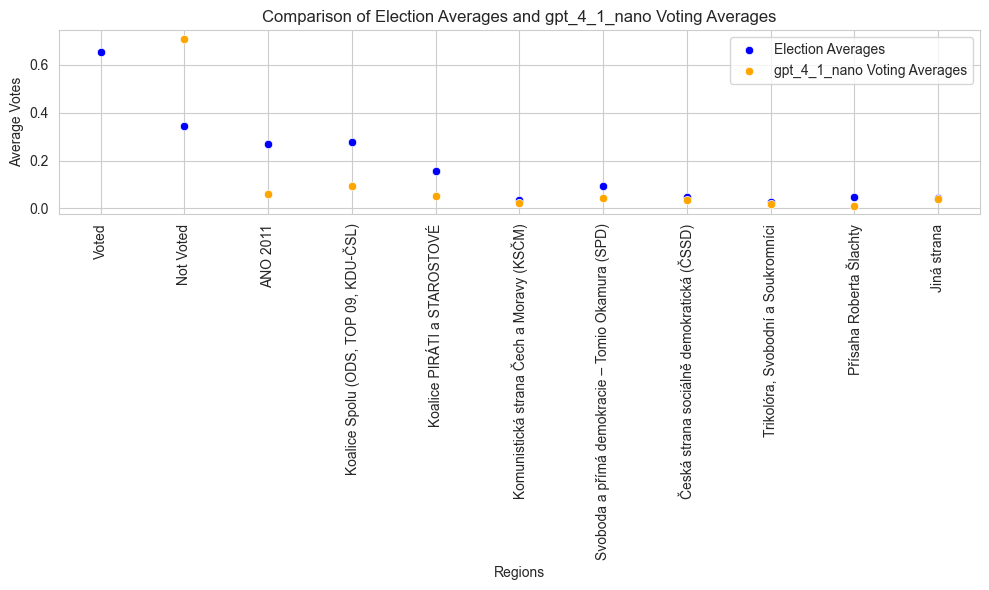

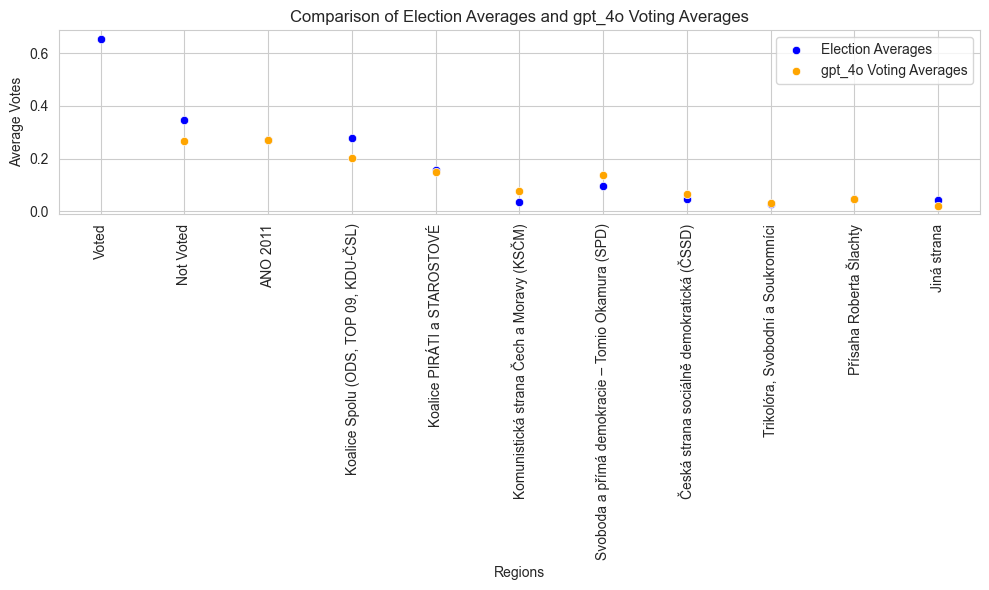

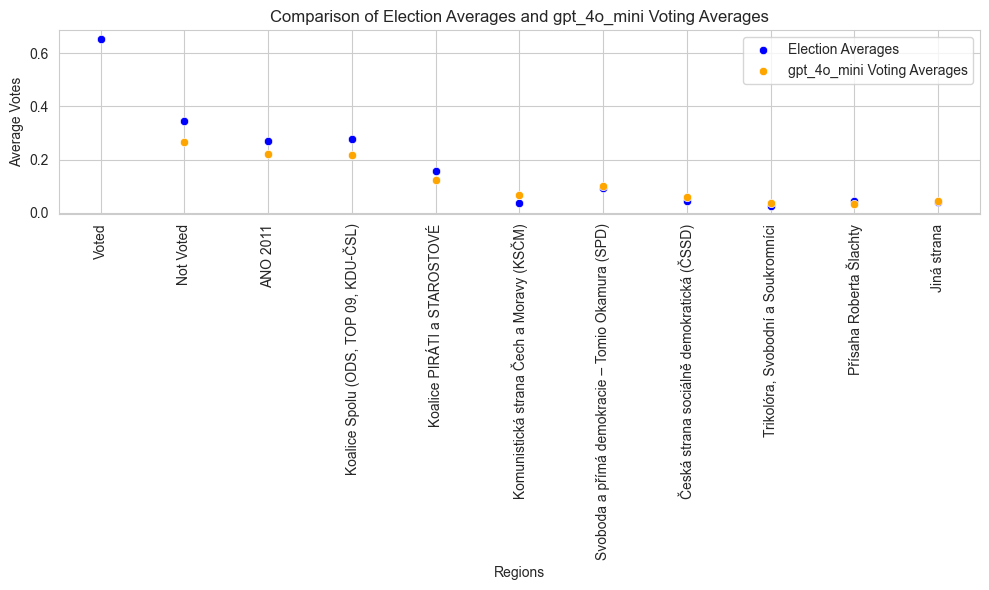

In [121]:
for model in voting_results_dict:
    voting_avgs_df = voting_results_dict[model].mean().drop(index=[VOTED])
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=election_averages_df.index, y=election_averages_df['average'], label='Election Averages', color='blue')
    sns.scatterplot(x=voting_avgs_df.index, y=voting_avgs_df, label=f'{model} Voting Averages', color='orange')
    plt.xticks(rotation=90)
    plt.title(f'Comparison of Election Averages and {model} Voting Averages')
    plt.xlabel('Regions')
    plt.ylabel('Average Votes')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [122]:
from scipy.stats import entropy
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance

# Initialize a dictionary to store metrics
metrics = {}

voting_avgs_dict = {model: voting_results_dict[model].mean().drop(index=[VOTED]) for model in voting_results_dict}
voting_avgs_dict.update({'claimed': claimed_votes_df.drop(index=[VOTED])})
el_avg = election_averages_df.drop(index=[VOTED]).astype(float)
# voting_avgs_dict = {model: voting_results_dict[model].mean() for model in voting_results_dict}
# voting_avgs_dict.update({'claimed': claimed_votes_df})
# election_averages_df = pd.DataFrame(election_data.drop('region', axis=1).mean(), columns=['average'])

for model, df in voting_avgs_dict.items():
    # Normalize distributions to ensure they sum to 1
    election_probs = np.array(el_avg['average'] / el_avg['average'].sum())
    model_probs = np.array(df / df.sum())
    # print(model, model_probs.shape, election_probs.shape)
    # print(model_probs)
    # print(election_probs)
    # print(type(model_probs), type(election_probs))
    # Calculate metrics
    mae = np.mean(np.abs(election_probs - model_probs))
    rmse = np.sqrt(np.mean((election_probs - model_probs) ** 2))
    correlation = np.corrcoef(election_probs, model_probs)[0, 1]
    kl_div = entropy(election_probs, model_probs)  # KL Divergence
    js_div = jensenshannon(election_probs, model_probs) ** 2  # Jensen-Shannon Divergence
    wasserstein = wasserstein_distance(election_probs, model_probs)  # Wasserstein Distance

    metrics[model] = {
        'MAE': mae,
        'RMSE': rmse,
        'Correlation': correlation,
        'KL Divergence': kl_div,
        'Jensen-Shannon Divergence': js_div,
        'Wasserstein Distance': wasserstein
    }

# Display metrics
metrics_df = pd.DataFrame(metrics).T
metrics_df

,MAE,RMSE,Correlation,KL Divergence,Jensen-Shannon Divergence,Wasserstein Distance
gpt_4_1,0.060908,0.086630,0.508442,0.243018,0.064152,0.024546
gpt_4_1_nano,0.080148,0.140990,0.691029,0.390565,0.092093,0.079465
gpt_4o,0.026844,0.036218,0.908339,0.082626,0.023239,0.018492
gpt_4o_mini,0.015943,0.018137,0.991654,0.021571,0.005751,0.014979
claimed,0.030735,0.039159,0.894563,0.084691,0.020106,0.015019


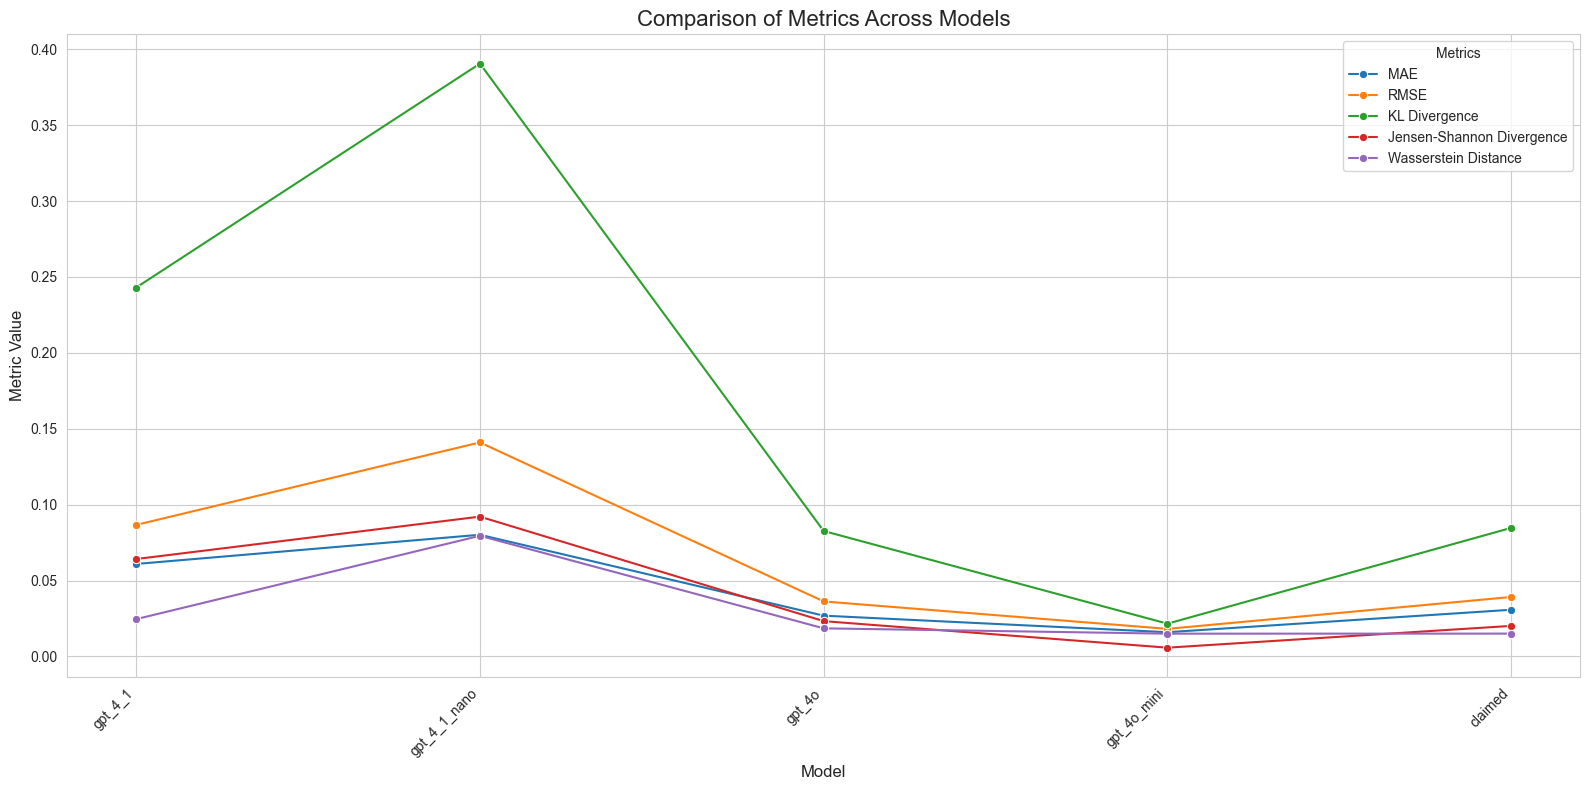

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset the index of metrics_df for plotting
metrics_df_reset = metrics_df.drop(columns=['Correlation']).reset_index().melt(id_vars='index', var_name='Metric', value_name='Value')


# Create the line plot
plt.figure(figsize=(16, 8))
sns.lineplot(data=metrics_df_reset, x='index', y='Value', hue='Metric', marker='o')

# Customize the plot
plt.title('Comparison of Metrics Across Models', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Metric Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metrics',  loc='upper right')
plt.tight_layout()

# Show the plot
plt.show()

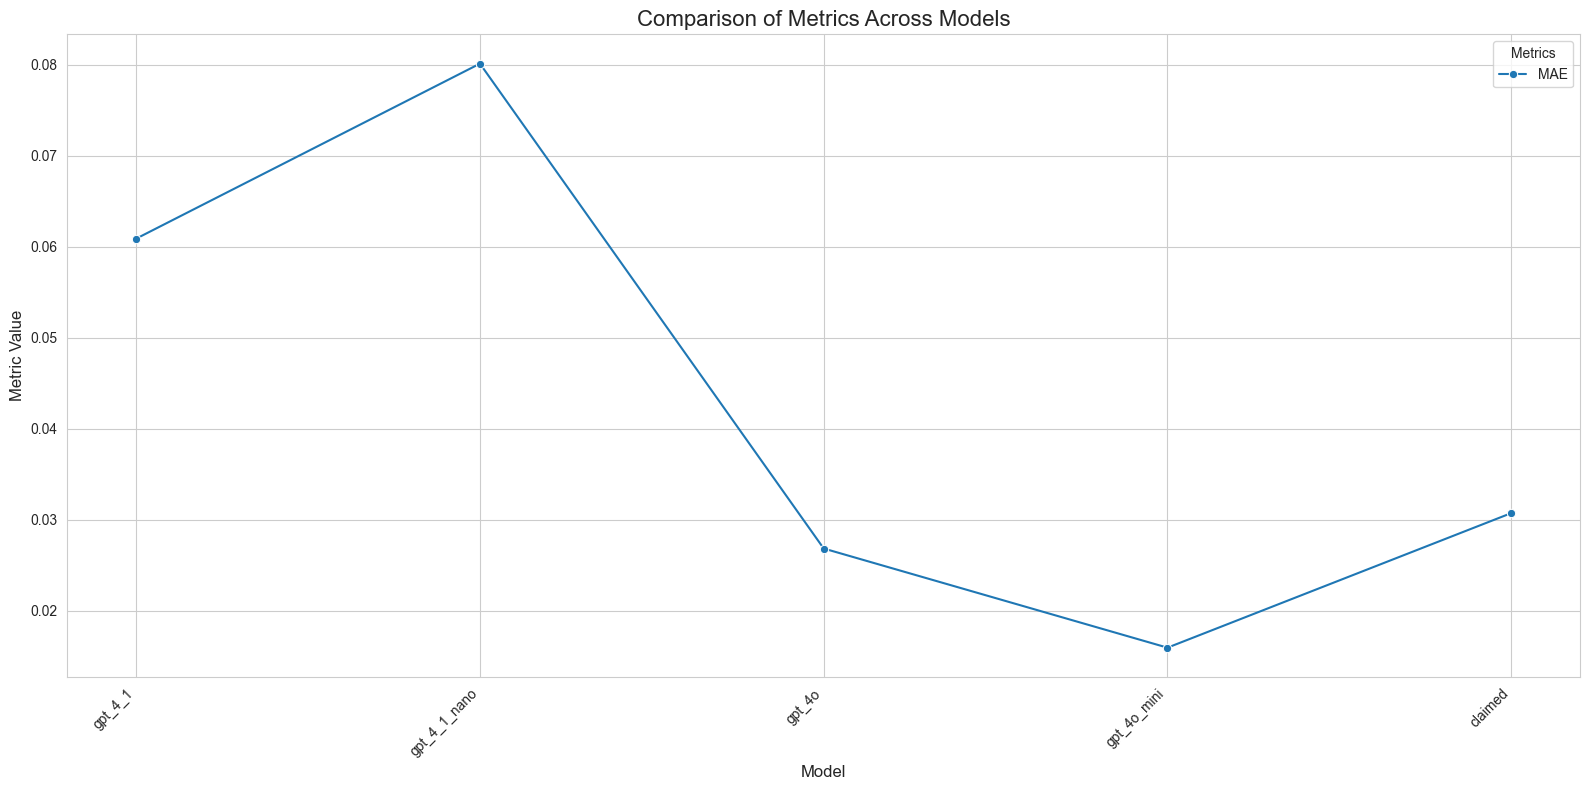

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset the index of metrics_df for plotting
metrics_df_reset = metrics_df.drop(columns=['Correlation']).reset_index().melt(id_vars='index', var_name='Metric', value_name='Value')
metrics_df_reset = metrics_df_reset[metrics_df_reset['Metric'].isin(['MAE'])]#, 'KL Divergence'])]


# Create the line plot
plt.figure(figsize=(16, 8))
sns.lineplot(data=metrics_df_reset, x='index', y='Value', hue='Metric', marker='o')

# Customize the plot
plt.title('Comparison of Metrics Across Models', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Metric Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metrics',  loc='upper right')
plt.tight_layout()

# Show the plot
plt.show()

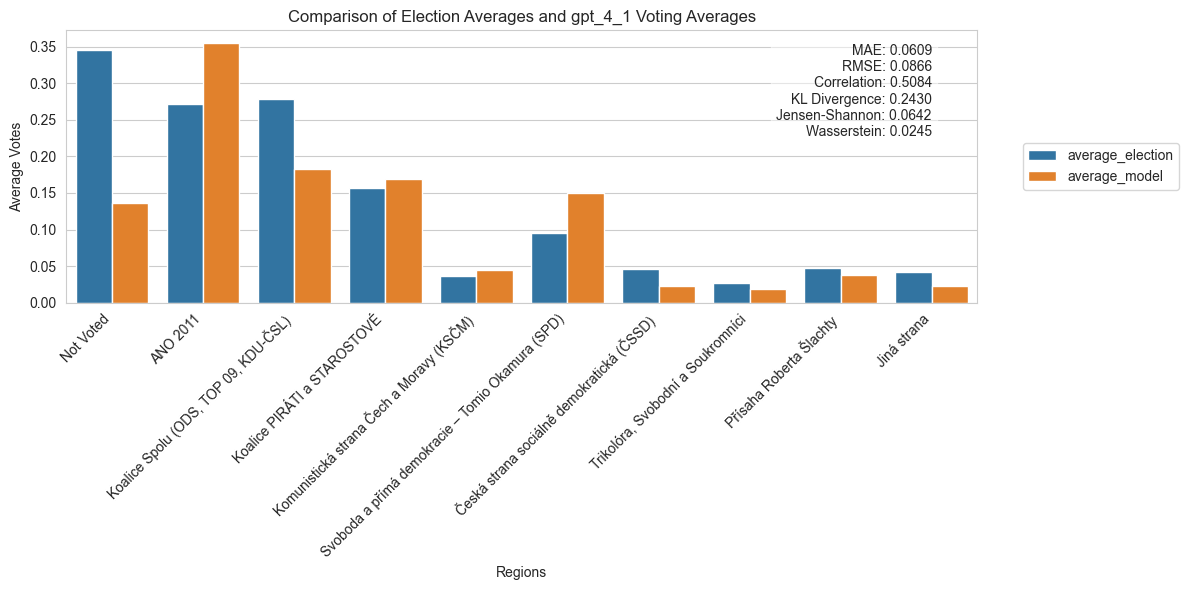

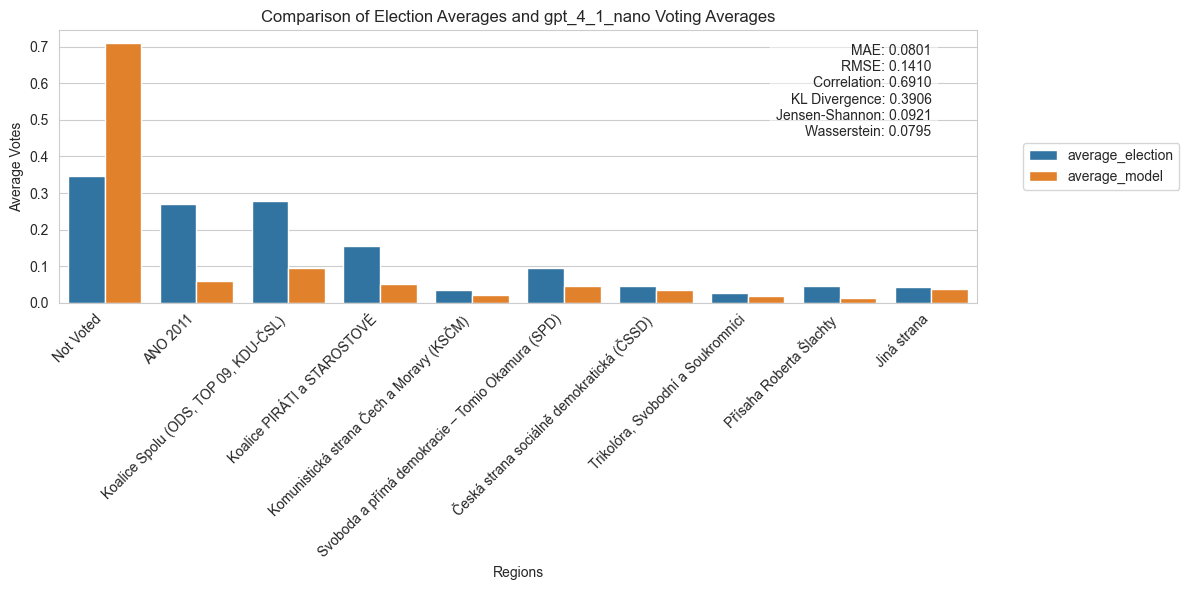

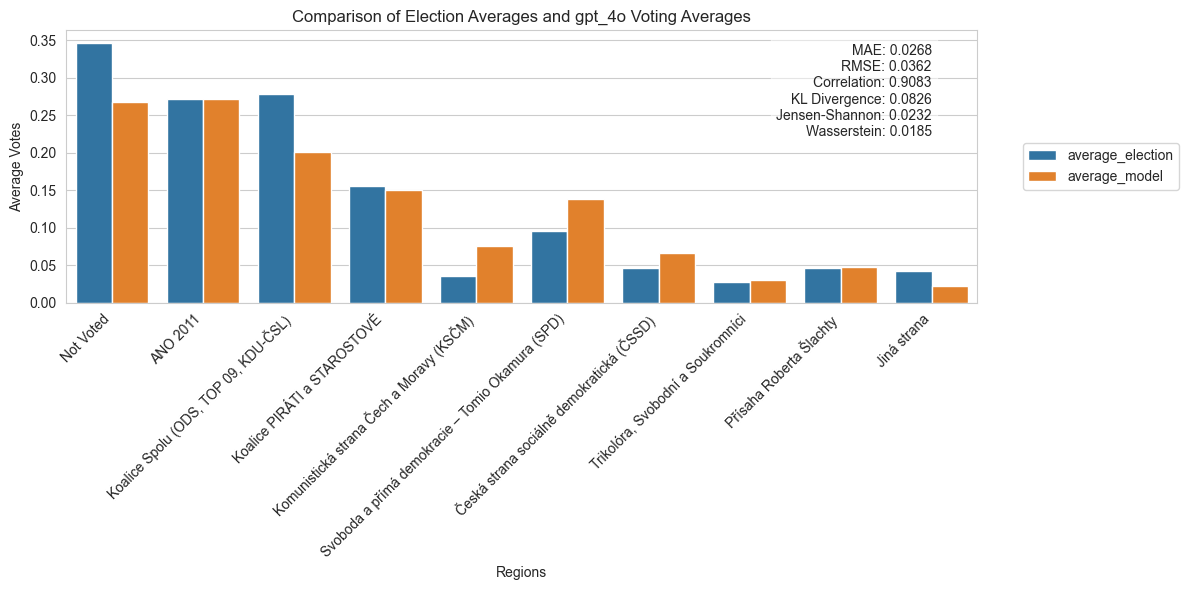

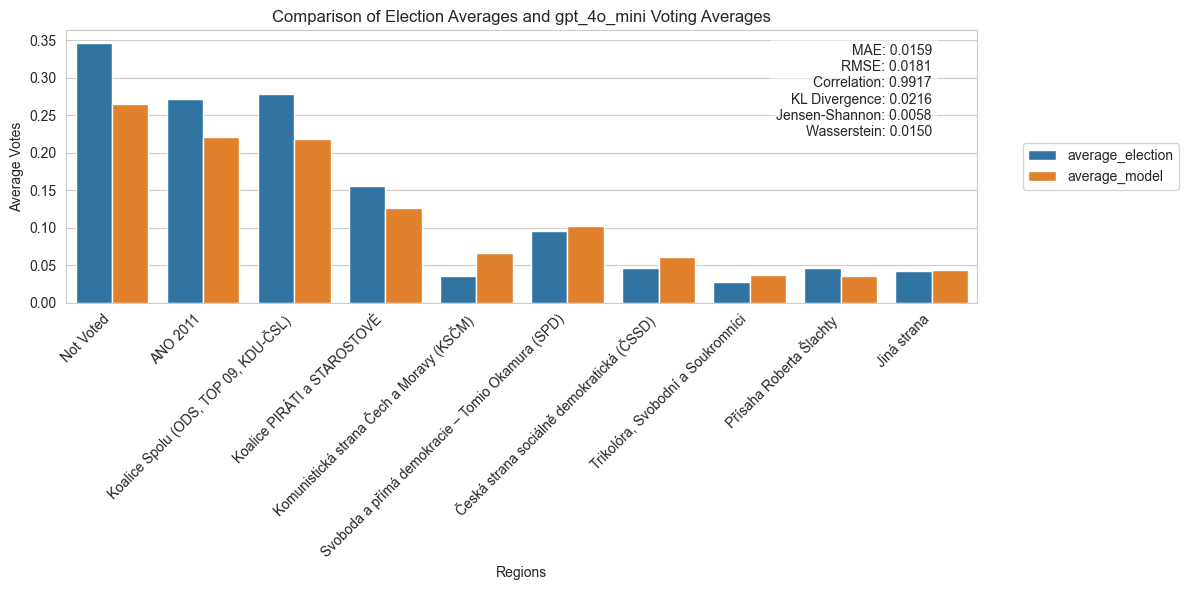

In [125]:
# Iterate through models
for model in voting_results_dict:
    # voting_avgs_df = voting_results_dict[model].mean().drop(index=['Voted']).sort_index()
    voting_avgs_df = pd.DataFrame(voting_results_dict[model].mean(), columns = ['average'])
    voting_avgs_df = voting_avgs_df.rename_axis('party')

    # Combine data into a single DataFrame for side-by-side bar plot
    tmp_df = election_averages_df.join(voting_avgs_df, lsuffix='_election', rsuffix='_model').reset_index()
    tmp_df = tmp_df[tmp_df.party != 'Voted']
    combined_df = tmp_df.melt(id_vars='party', var_name='Type', value_name='Average')

    # Visualization: Side-by-Side Bar Chart using Seaborn
    plt.figure(figsize=(12, 6))
    sns.barplot(data=combined_df, x='party', y='Average', hue='Type')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Comparison of Election Averages and {model} Voting Averages')
    plt.xlabel('Regions')
    plt.ylabel('Average Votes')

    # Add metrics as text annotations in the upper-right corner
    metrics_text = (
        f"MAE: {metrics[model]['MAE']:.4f}\n"
        f"RMSE: {metrics[model]['RMSE']:.4f}\n"
        f"Correlation: {metrics[model]['Correlation']:.4f}\n"
        f"KL Divergence: {metrics[model]['KL Divergence']:.4f}\n"
        f"Jensen-Shannon: {metrics[model]['Jensen-Shannon Divergence']:.4f}\n"
        f"Wasserstein: {metrics[model]['Wasserstein Distance']:.4f}"
    )
    plt.text(
        0.95, 0.95, metrics_text, fontsize=10, verticalalignment='top',
        horizontalalignment='right', transform=plt.gca().transAxes,
        bbox=dict(facecolor='white', alpha=0.5)
    )

    # Place the legend below the text box
    plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.)

    plt.tight_layout()
    plt.show()

In [126]:
tmp_df.sum()

party               Not VotedANO 2011Koalice Spolu (ODS, TOP 09, K...
average_election                                               1.3457
average_model                                                1.176412
dtype: object

In [127]:
voting_results_gpt_4_1.sum(axis=1)

0       2.0
1       2.0
2       2.0
3       2.0
4       2.0
       ... 
3875    2.0
3876    2.0
3877    2.0
3878    2.0
3879    2.0
Length: 3880, dtype: float64